<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="https://www.uoc.edu/content/dam/news/images/noticies/2016/202-nova-marca-uoc.jpg" align="left" width="45%">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.891 · Aprenentatge automàtic · PAC3</p>
<p style="margin: 0; text-align:right;">2025-2 · Màster universitari en Ciència de dades (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudis d'Informàtica, Multimèdia i Telecomunicació</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

# PAC 3: Mètodes supervisats

En aquesta pràctica veurem diferents mètodes supervisats i tractarem d'optimitzar diferents mètriques. Veurem com els diferents models classifiquen les observacions i amb quins obtindrem un major rendiment. Després aplicarem tot el que sabem d'anàlisi, preprocessament de dades i regressió a un dataset nou simulant un cas pràctic real.

1. [Exploració d'algorismes supervisats](#ej1) \
    1.1. [Càrrega de dades](#ej11) \
    1.2. [K veïns més propers (KNN)](#ej13) \
    1.3. [Màquines de suport vectorial (SVM)](#ej14) \
    1.4. [Arbres de decisió](#ej15)
4. [Implementació del cas pràctic](#ej2)\
    2.1. [Càrrega de dades](#ej21) \
    2.2. [Anàlisi estadística bàsica i exploratòria de dades](#ej22) \
    2.3. [Preprocessament de dades](#ej23) \
    2.4. [Modelització](#ej24) \
    2.5. [TabPFN](#ej25)

<u>Consideracions generals</u>:

- La solució plantejada no pot utilitzar mètodes, funcions o paràmetres declarats **_deprecated_** en futures versions, a excepció de la càrrega de dades com s'indica posteriorment.
- Aquesta PAC s'ha de realitzar de forma **estrictament individual**. Qualsevol indici de còpia serà penalitzat amb un suspens (D) per a totes les parts implicades i la possible avaluació negativa de l'assignatura de forma íntegra.
- Cal que l'estudiant indiqui **totes les fonts** que ha utilitzat per a la realització de la PAC. En cas contrari, es considerarà que l'estudiant ha comès plagi, essent penalitzat amb un suspens (D) i la possible avaluació negativa de l'assignatura de forma íntegra.
- En aquesta PAC es permet l'ús de la IA per a explorar millores en les visualitzacions creades i per a aprofundir en l'anàlisi dels resultats que hàgiu obtingut pel vostre compte, sempre detallant els prompts i respostes produïdes i des d'una perspectiva crítica que inclogui la vostra argumentació, deixant clar en què esteu d'acord amb la IA i en què no.

<u>Format de l'entrega</u>:

- Alguns exercicis poden suposar diversos minuts d'execució, per la qual cosa l'entrega s'ha de fer en **format notebook** i en **format html**, on es vegi el codi, els resultats i comentaris de cada exercici. Es pot exportar el notebook a HTML des del menú File $\to$ Download as $\to$ HTML.
- Existeix un tipus de cel·la especial per a albergar text. Aquest tipus de cel·la us serà molt útil per a respondre a les diferents preguntes teòriques plantejades al llarg de l'activitat. Per a canviar el tipus de cel·la a aquest tipus, al menú: Cell $\to$ Cell Type $\to$ Markdown.

<div class="alert alert-block alert-info">
<strong>Nom i cognoms:</strong> Carles Trullàs Fernández
</div>

La cel·la següent carrega la major part dels mòduls que necessitareu per al desenvolupament de la tercera PAC.

In [53]:
import os
import pickle
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn import tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
    )
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from umap import UMAP

<a id='ej1'></a>
# 1. Exploració d'algoritmes supervisats (4,5 punts)

En aquest apartat explorarem el comportament de les diferents tècniques de classificació vistes a la teoria aplicades a un conjunt de dades molt visual.

<a id='ej11'></a>
## 1.1. Càrrega i preparació de les dades (0,75 punts)

El conjunt de dades EMNIST (Extended Modified National Institute of Standards and Technology) és una ampliació del clàssic MNIST dataset, àmpliament utilitzat en tasques de visió per computador. Mentre que MNIST conté únicament imatges de dígits manuscrits (0–9), EMNIST incorpora també lletres de l'alfabet (majúscules i/o minúscules, segons la partició), la qual cosa el converteix en un recurs més complet i desafiant per a entrenar i avaluar models de reconeixement de caràcters. <i>Cohen, G., Afshar, S., Tapson, J., & van Schaik, A. (2017). EMNIST: an extension of MNIST to handwritten letters. Retrieved from http://arxiv.org/abs/1702.05373</i>

En aquesta activitat utilitzarem el subconjunt de les lletres majúscules (A, J, L, M, S) projectades a un espai de dues dimensions per a poder entendre de forma visual com funciona cadascun dels algoritmes de classificació plasmant les seves fronteres de decisió.

El primer que farem és carregar el conjunt de dades:

In [3]:
# Carreguem el conjunt de dades EMNIST (les lletres A, J, L, M, S)
with open('data/EMNIST_sample-1.pickle', 'rb') as dump_file:
    X, y = pickle.load(dump_file)

n_classes = np.unique(y).size
print(f"# clases: {n_classes}")

labels = ["A", "J", "L", "M", "S"]

# clases: 5


Amb el codi següent veurem un exemple d'imatge de cadascuna de les classes. Per això reajustarem el vector de 784 dimensions que representa cada imatge en una matriu de mida 28x28 per poder-la mostrar:

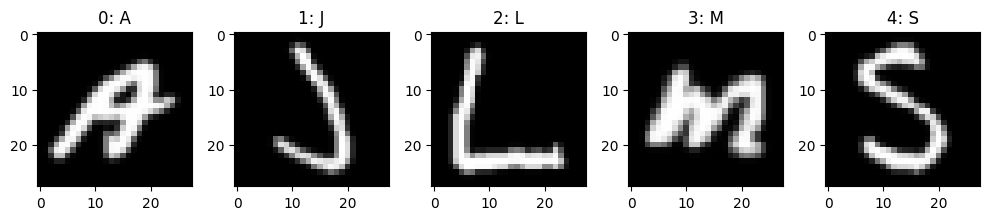

In [4]:
# Mostrem un exemple de cada classe reajustant el vector de 784 dimensions a una matriu 28x28
fig, ax = plt.subplots(1, n_classes, figsize=(10, 5))

idxs = [np.where(y == i)[0] for i in range(n_classes)]

for i in range(n_classes):
    k = np.random.choice(idxs[i])
    ax[i].imshow(X[k].reshape(28, 28), cmap="gray")
    ax[i].set_title("{}".format(f"{i}: {labels[i]}"))

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<strong>Implementació:</strong>

Dividiu el _dataset_ en dos subconjunts, __*train*__ (80% de les dades) i __*test*__ (20% de les dades). Nomeneu els conjunts com: X_train, X_test, y_train, y_test. Utilitzeu l'opció `random_state = 24`. Podeu utilitzar la implementació `train_test_split` de `sklearn`.    

</div>

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=24, stratify=y
)

print(f"mida conjunt entrenament: {X_train.shape}")
print(f"mida conjunt de test: {X_test.shape}")

mida conjunt entrenament: (5992, 784)
mida conjunt de test: (1499, 784)


Per poder visualitzar els resultats de cada algorisme supervisat, reduirem el dataset anterior a dues dimensions.

<div class="alert alert-block alert-info">
<strong>Implementació:</strong>

Utilitza UMAP per a reduir tant el conjunt de dades d'entrenament com de test a dues dimensions.    

</div>

In [6]:
# reduïm les dades a 2 dims amb umap
umap_reducer = UMAP(n_components=2, random_state=42)

# ajustem tant train com test
X_train_2d = umap_reducer.fit_transform(X_train)
X_test_2d = umap_reducer.transform(X_test)

print(f"mida train: {X_train_2d.shape}")
print(f"mida test: {X_test_2d.shape}")

c:\Users\CarlesTF\miniconda3\envs\uoc2026pec3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


mida train: (5992, 2)
mida test: (1499, 2)


Al llarg de l'exercici aprendrem a veure gràficament les fronteres de decisió que ens tornen els diferents models. Per això utilitzarem la funció definida a continuació, que segueix els passos següents:

1. Crear una meshgrid amb els valors mínim i màxim de 'x' i 'y'.
2. Predir el classificador amb els valors de la meshgrid.
3. Fer un rebuig de les dades per tenir el format corresponent.

Un cop fet això, ja podem fer el gràfic de les fronteres de decisió i afegir-hi els punts reals. Així veurem les àrees que el model considera que són duna classe i les que considera que són duna altra. En posar a sobre els punts veurem si els classifica correctament a l'àrea que els correspon.

In [7]:
# Define the function that will visualize the decision boundary
def plot_decision_boundaries(model, X_test_projection, y_test):

    # Create the meshgrid with the minimum and maximum values of the x and y axes
    x_min, x_max = X_test_projection[:, 0].min() - 1, X_test_projection[:, 0].max() + 1
    y_min, y_max = X_test_projection[:, 1].min() - 1, X_test_projection[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))

    # Prediction by using all values of the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Define the colors (one for each class)
    cmap_light = ListedColormap(['gainsboro','lightgreen','peachpuff','lightcyan', 'pink'])
    cmap_bold = ['grey', 'g','sandybrown','c','palevioletred']

    # Draw the borders
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(20,10))
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    # Draw the points
    for i in range(n_classes):
        plt.scatter(X_test_projection[y_test == i,0], X_test_projection[y_test == i,1],
                    s=40, marker='o', label=labels[i], c=cmap_bold[i])
    plt.legend(loc='best')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.show()

<a id='ej12'></a>
## 1.2. KNN (1,25 punts)

En aquest punt, entendràs el funcionament de l'algoritme KNN (K-Nearest-Neighbor), que es basa en la proximitat dels punts de dades en un espai de característiques. Analitzaràs els seus avantatges i desavantatges, i comprendràs com els paràmetres que el componen influeixen en el seu comportament.

KNN és un algoritme de tipus supervisat basat en instància. Això significa:

- Supervisat: El teu conjunt de dades d'entrenament està etiquetat amb la classe o resultat esperat.
- Basat en instància (_Lazy Learning_): L'algoritme no aprèn explícitament un model, com en la Regressió Logística o els arbres de decisió. En canvi, memoritza les instàncies d'entrenament i les utilitza com a "coneixement" en la fase de predicció.

Per a entendre com funciona KNN, segueix aquests passos:

1. Calcula la distància entre l'ítem a classificar i els altres ítems del dataset d'entrenament.
2. Selecciona els "k" elements més propers, és d'acord, aquells amb la menor distància, segons el tipus de distància que utilitzis (euclídia, cosinus, manhattan, etc).
3. Realitza una "votació de majoria" entre els k punts seleccionats: la classe que predomini en aquests punts decidirà la classificació final de l'ítem analitzat.

<div class="alert alert-block alert-info">
<strong>Implementació:</strong>

Realitza els següents passos amb el dataset d'entrenament (_train_):

1. Entrena un classificador KNN amb l'hiperparàmetre `n_neighbors=2` usant el classificador `KNeighborsClassifier` de `sklearn`.
2. Calcula l'*accuracy* (precisió) del model tant en les dades de _train_ com de _test_.
3. Calcula la matriu de confusió utilitzant les dades de _test_.
4. Representa gràficament la frontera de decisió amb les dades de _test_.

Si en entrenar el classificador apareix un avís (warning) i desitges ignorar-lo, executa el següent codi abans de l'entrenament:

`import warnings`
`warnings.filterwarnings('ignore', message='^.*will change.*$', category=FutureWarning)`"

Això et permetrà avaluar l'efectivitat del model KNN amb `n_neighbors=2` en el teu conjunt de dades, i entendre com es comporta en termes de classificació i separació de classes.    
    
    
    
</div>

accuracy train (k=2): 0.9800
accuracy test  (k=2): 0.9540


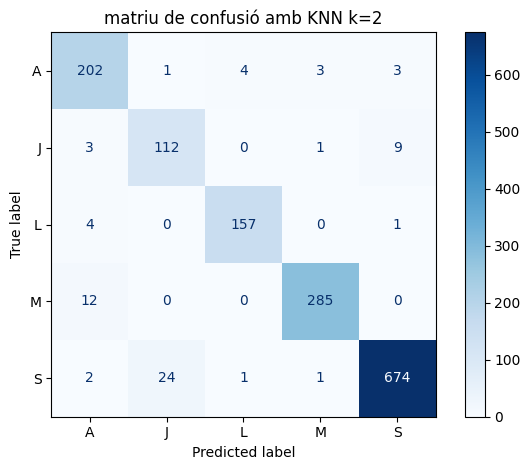

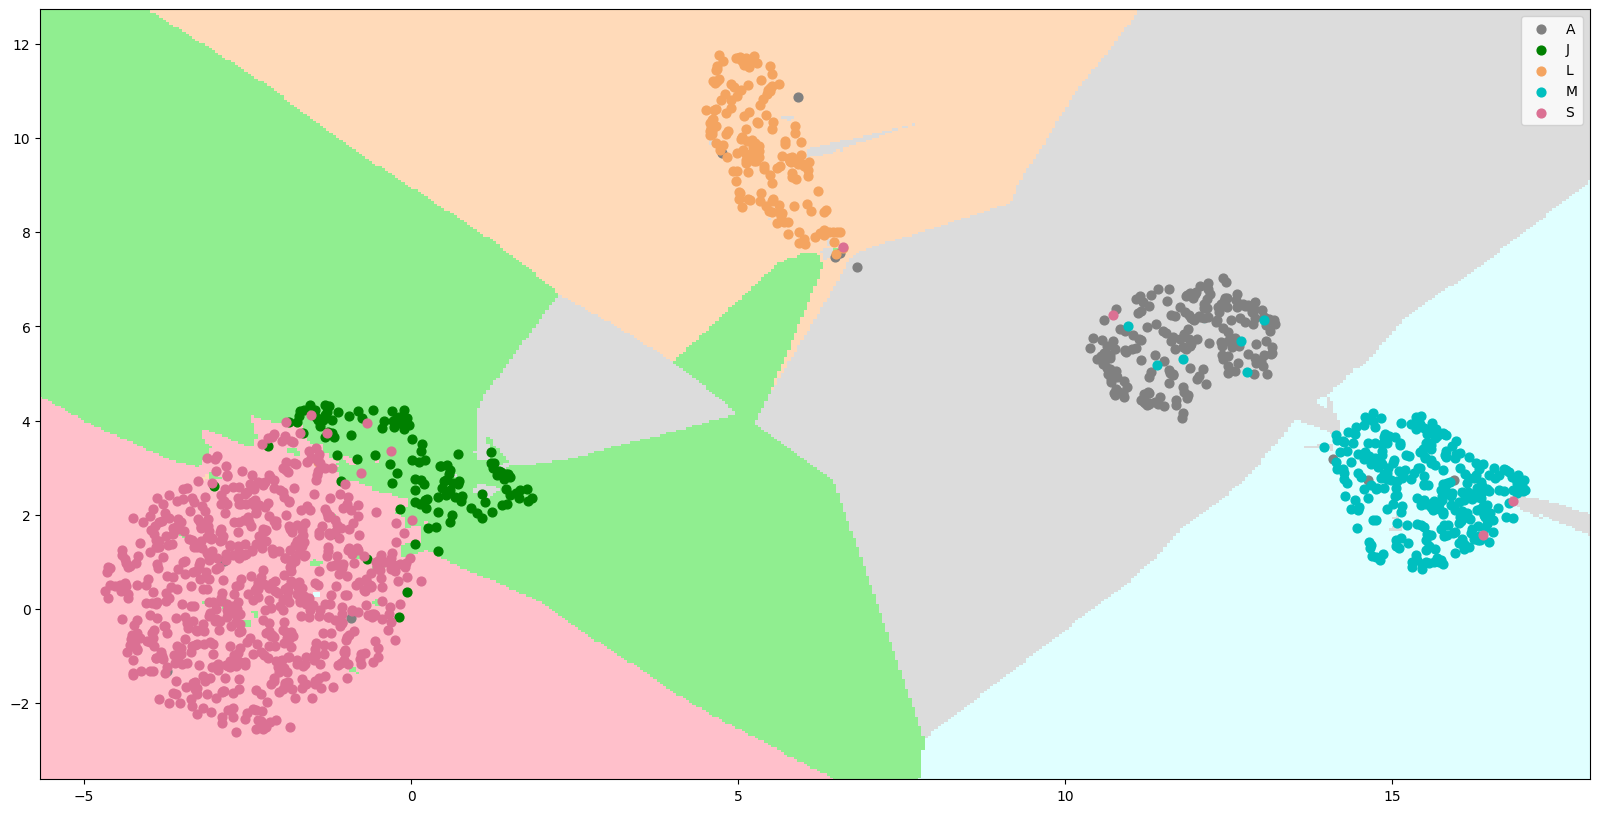

In [8]:
warnings.filterwarnings('ignore', message='^.*will change.*$', category=FutureWarning)

# entrenem amb k=2 veïns
knn_2 = KNeighborsClassifier(n_neighbors=2)
knn_2.fit(X_train_2d, y_train)

# calculem accuracy a train i test
acc_train_knn2 = accuracy_score(y_train, knn_2.predict(X_train_2d))
acc_test_knn2  = accuracy_score(y_test,  knn_2.predict(X_test_2d))
print(f"accuracy train (k=2): {acc_train_knn2:.4f}")
print(f"accuracy test  (k=2): {acc_test_knn2:.4f}")

# matriu de confusió sobre test
cm_knn2 = confusion_matrix(y_test, knn_2.predict(X_test_2d))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn2, display_labels=labels)
disp.plot(cmap='Blues')
plt.title("matriu de confusió amb KNN k=2")
plt.tight_layout()
plt.show()

# fem plot de les fronteres de decisió
plot_decision_boundaries(knn_2, X_test_2d, y_test)

En el model que has entrenat, has fixat el paràmetre `n_neighbors` de forma arbitrària. No obstant això, és possible que amb un altre valor obtinguis una millor predicció. Per a trobar el valor òptim dels paràmetres d'un model (_hyperparameter tunning_), sovint s'utilitza una cerca de graella (_grid search_). Això implica entrenar un model per a cada combinació possible d'hiperparàmetres i avaluar-lo mitjançant validació creuada (_cross validation_) amb 5 particions estratificades. Després, seleccionaràs la combinació d'hiperparàmetres que hagi obtingut els millors resultats.

En aquest cas, et centraràs en optimitzar un sol hiperparàmetre:

- 𝑘: el nombre de veïns que es consideren per a classificar un nou exemple. Has de provar amb tots els valors entre 1 i 20.

Realitza aquest procés per a identificar el nombre òptim de veïns, la qual cosa et permetrà millorar la precisió de les teves prediccions amb el model KNN.

<div class="alert alert-block alert-info">
    <strong>Implementació:</strong>

Per a calcular el valor òptim de l'hiperparàmetre _k_ (`n_neighbors`), has de realitzar una cerca de graella amb validació creuada. Aquest procés t'ajudarà a trobar el valor òptim de _k_. Per a cada valor, calcula la seva mitjana i la desviació estàndard. Després, implementa un _lineplot_ per a visualitzar la precisió segons els diferents valors de l'hiperparàmetre.

Utilitza el mòdul `GridSearchCV` de `sklearn` per a calcular el millor hiperparàmetre. Per a la visualització del _lineplot_, empra la llibreria `Seaborn`.

Aquests passos et permetran identificar de manera efectiva i visual el valor de _k_ que maximitza la precisió del teu model KNN."
</div>

millor k: 15
millor accuracy CV: 0.9798


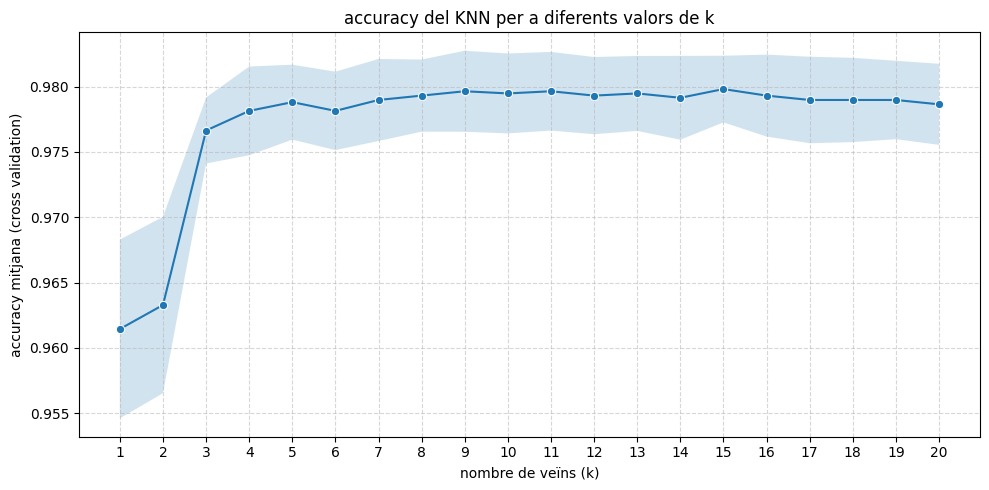

In [9]:
# cross validation per trobar el millor k entre 1 i 20
param_grid_knn = {'n_neighbors': list(range(1, 21))}
cv_knn = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=cv_knn,
    scoring='accuracy',
    return_train_score=True
)
grid_knn.fit(X_train_2d, y_train)

# calculem mitjana i desviació estàndard de l'accuracy per a cada k
cv_results_knn = pd.DataFrame({
    'k': list(range(1, 21)),
    'mean_accuracy': grid_knn.cv_results_['mean_test_score'],
    'std_accuracy':  grid_knn.cv_results_['std_test_score']
})

print(f"millor k: {grid_knn.best_params_['n_neighbors']}")
print(f"millor accuracy CV: {grid_knn.best_score_:.4f}")

# lineplot de l'accuracy en funció de k
plt.figure(figsize=(10, 5))
sns.lineplot(data=cv_results_knn, x='k', y='mean_accuracy', marker='o')
plt.fill_between(
    cv_results_knn['k'],
    cv_results_knn['mean_accuracy'] - cv_results_knn['std_accuracy'],
    cv_results_knn['mean_accuracy'] + cv_results_knn['std_accuracy'],
    alpha=0.2
)
plt.xlabel("nombre de veïns (k)")
plt.ylabel("accuracy mitjana (cross validation)")
plt.title("accuracy del KNN per a diferents valors de k")
plt.xticks(range(1, 21))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<strong>Implementació:</strong>

Segueix aquests passos amb el dataset d'entrenament (_train_):

1. Entrena un classificador KNN utilitzant el millor hiperparàmetre que hagis trobat.
2. Calcula l'*accuracy* (precisió) del model tant en les dades de _train_ com de _test_.
3. Calcula la matriu de confusió utilitzant les dades de _test_.
4. Representa gràficament la frontera de decisió amb les dades de _test_.

Aquest procés et permetrà veure com l'hiperparàmetre òptim que has identificat millora l'efectivitat del teu model KNN en la classificació de les dades.
</div>

millor k: 15
accuracy en train (millor k): 0.9796
accuracy en test  (millor k): 0.9733


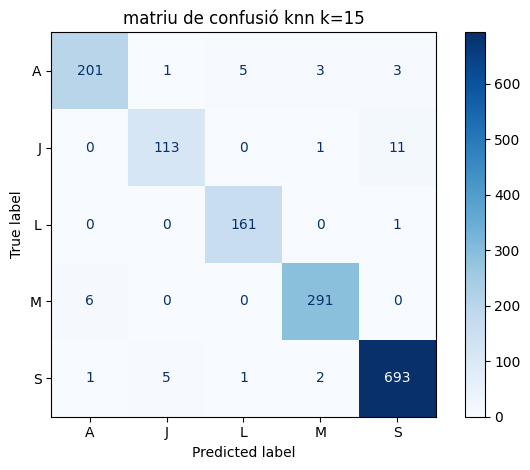

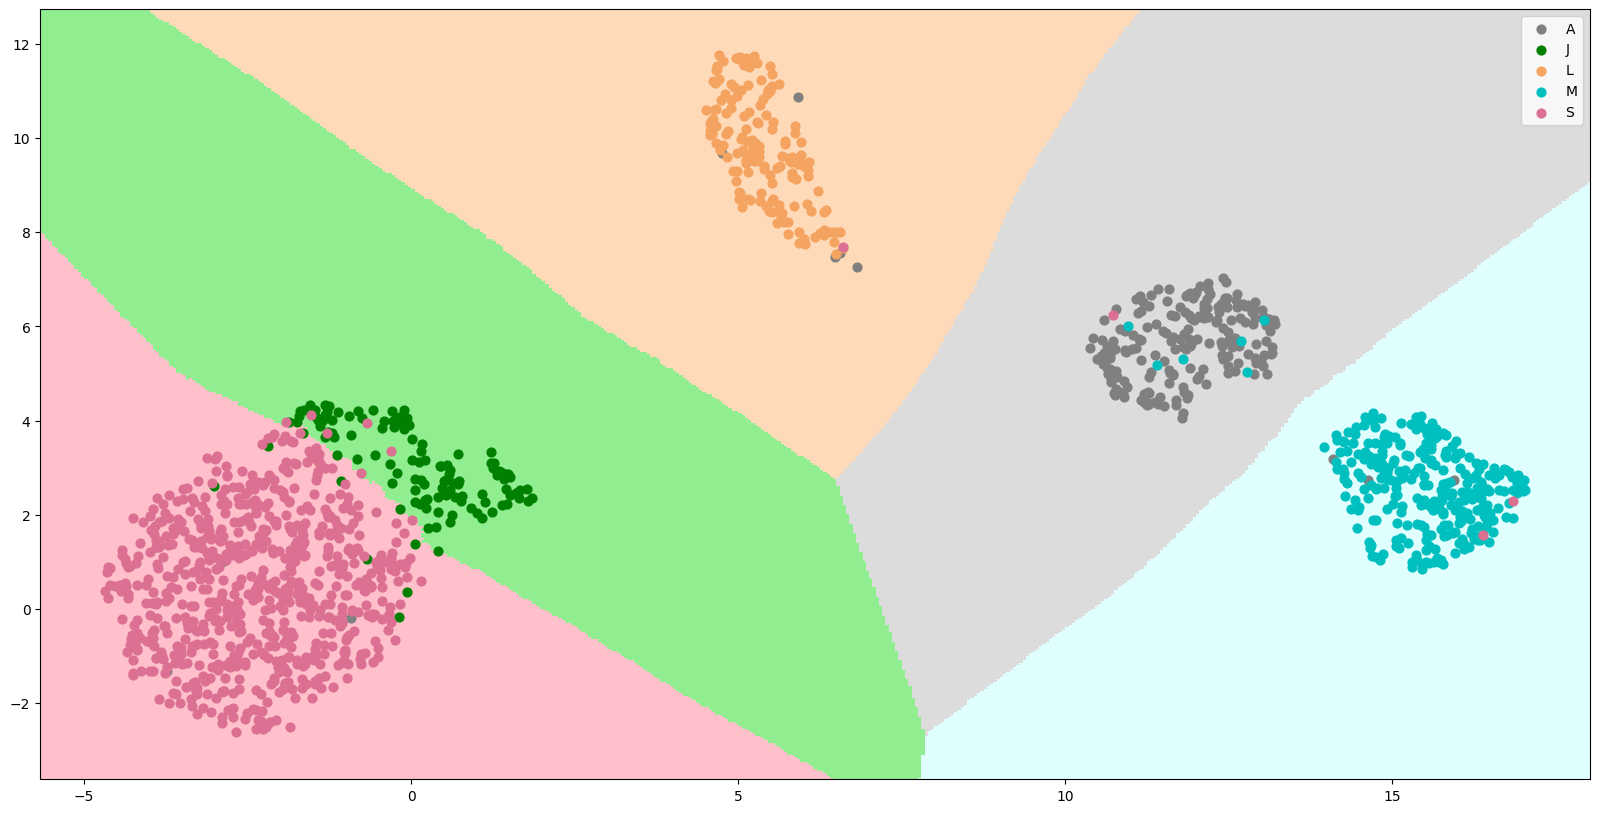

In [10]:
best_k = grid_knn.best_params_['n_neighbors']

# entrenem KNN amb el millor hiperparàmetre trobat
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_2d, y_train)

# accuracy en train i test
acc_train_knn_best = accuracy_score(y_train, knn_best.predict(X_train_2d))
acc_test_knn_best  = accuracy_score(y_test,  knn_best.predict(X_test_2d))
print(f"millor k: {best_k}")
print(f"accuracy en train (millor k): {acc_train_knn_best:.4f}")
print(f"accuracy en test  (millor k): {acc_test_knn_best:.4f}")

# matriu de confusió
cm_knn_best = confusion_matrix(y_test, knn_best.predict(X_test_2d))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn_best, display_labels=labels)
disp.plot(cmap='Blues')
plt.title(f"matriu de confusió knn k={best_k}")
plt.tight_layout()
plt.show()

# fronteres de decisió
plot_decision_boundaries(knn_best, X_test_2d, y_test)

<div class="alert alert-block alert-info">
<strong>Anàlisi:</strong>

1. Comenta els resultats obtinguts en la cerca del millor hiperparàmetre. Reflexiona sobre com va variar el rendiment del model amb els diferents valors de `n_neighbors`.
2. Analitza com es visualitza gràficament el canvi del valor de `n_neighbors`. Observes alguna tendència o patró clar? És coherent aquesta diferència entre els dos gràfics en canviar el paràmetre?
3. Examina les fronteres de decisió que has generat. La forma d'aquestes fronteres té sentit donat l'algoritme KNN utilitzat? Pensa en com l'elecció del nombre de veïns influeix en la forma de la frontera.
4. Avalua les prediccions realitzades sobre el conjunt de test. Observa la seva precisió i com es distribueixen en relació amb les fronteres de decisió. Són aquestes prediccions consistents amb el que observes en les fronteres de decisió?

Aquest anàlisi t'ajudarà a comprendre l'eficàcia del model KNN amb diferents configuracions de `n_neighbors` i el seu impacte en la classificació de les dades."
</div>

Preguntes 1 i 2: 

- La gràfica mostra que l'accuracy augmenta ràpidament quan k passa d'1 a pocs veïns. 
- El canvi més gran es produeix en passar de k=2 a k=3. De k=8 a k=15 les millores s'estabilitzen, i a partir de k=15 el rendiment ja comença a baixar (i seguiria baixant si seguissim augmentant k). 
- Tot i que k=15 ha obtingut els millors resultats, la complexitat computacional a l'hora de predir és més gran que per valors de k més baixos que aporten rendiments similars. En datasets més gran ens hauriem de plantejar si perdre una mica de rendiment però reduïr la complexitat de computació.
- En knn, normalment la acuracy en funció de k segueix una parábola invertida. L'accuracy comença baix, va augmentant fins assolir un pic, i després comença a baixar. El motiu és que el nombre de punts que voten ha de ser suficientment gran perquè hi hagi varietat, però suficientment petit perquè només votin els veïns realment propers.
- Per k=15 (millor valor) tenim una accuracy del 97%, lleugerament més baixa que en train (com ha de passar), però molt semblant. El fet que la accuraccy a train i test sigui tan semblant ens indica que no hi ha overfitting.
- Per últim, observem que al lineplot la desviació estandard és petita per tots els valors de k, fet que ens diu que l'accuracy és bastant constant a tots els folds.

Preguntes 3 i 4:

- Si comparem els gràfics per k=2 i k=15, per k=15 les regions estan més definides, tot i que per k=2 la forma "base" és semblant. Simplement la versió per k=15 és com una versió millorada amb les regions més ben definides.
- Les fronteres del KNN no segueixen cap forma analítica preestablerta (com passa en les svm, que tècnicament són plans en alguna dimensió), sinó que depenen completament dels punts. 
- Quan k és petita (per exemple k=2) cada punt influeix massa en la votació, la qual cosa fa que el model sigui més sensible al soroll i genera fronteres més irregulars.
- En l'espai 2d obtingut amb umap s'observen regions que reflecteixen l'agrupament natural de les cinc lletres. Observem que la J i la S es confonen bastant (ho veiem a la confusion matrix i també al dibuix de les fronteres, ja que els punts d'ambues classes estan molt junts), cosa que té sentit ja que les dues lletres tenen una part circular a la seva grafia.
- El dibuix de les fronteres per k=15 quadra amb el valor de l'accuracy, ja que al dibuix podem veure com la majoria dels punts estan a la regió que els hi toca (la regió del seu color).

<a id='ej13'></a>
## 1.3. SVM (1,25 punts)

En aquesta secció, exploraràs les Màquines de Vectors de Suport (SVM), que es basen en el concepte del _Maximal Margin Classifier_ i l'hiperplà.

Un hiperplà en un espai p-dimensional es defineix com un subespai pla i afí de dimensions p-1. En dues dimensions, és una recta; en tres, un pla convencional. Per a dimensions majors a tres, encara que no és intuïtiu visualitzar-lo, el concepte es manté.

Quan els casos són perfectament separables de manera lineal, sorgeixen infinits possibles hiperplans. Per a seleccionar el classificador òptim, utilitza el concepte de _maximal margin hyperplane_, l'hiperplà que es troba més allunyat de totes les observacions d'entrenament. Aquest es defineix calculant la distància perpendicular mínima (marge) de les observacions a un hiperplà. L'hiperplà òptim és aquell que maximitza aquest marge.

En el procés d'optimització, has de tenir en compte que només les observacions al marge o que el violen (vectors suport) influeixen en l'hiperplà. Aquests vectors suport són els que defineixen el classificador.

#### Els _kernels_ en SVM

En situacions on no pots trobar un hiperplà que separi dues classes, és a dir, quan les classes no són linealment separables, pots utilitzar el truc del nucli (_kernel trick_). Aquest mètode et permet treballar en una dimensió nova on és possible trobar un hiperplà per a separar les classes.

Igual que amb el KNN, les SVM també depenen de diversos hiperparàmetres. En aquest cas, et centraràs en optimitzar dos hiperparàmetres:

1. **C**: la regularització, que és el valor de penalització dels errors en la classificació. Aquest valor indica el compromís entre obtenir l'hiperplà amb el marge més gran possible i classificar correctament el màxim nombre d'exemples. Has de provar els següents valors: 0.01, 0.1, 1, 10, 50, 100 i 200.
   
2. **Gamma**: un coeficient que multiplica la distància entre dos punts en el kernel radial. En termes simples, com més petit sigui gamma, més influència tindran dos punts propers. Has de provar els valors: 0.001, 0.01, 0.1, 1 i 10.

Per a validar el rendiment de l'algoritme amb cada combinació d'hiperparàmetres, utilitza la validació creuada (_cross-validation_) amb 5 particions estratificades.

<div class="alert alert-block alert-info">
    <strong>Implementació:</strong>


1. Calcula el valor òptim dels hiperparàmetres _C_ i _gamma_ utilitzant una cerca de graella amb validació creuada. Aquest procés t'ajudarà a trobar els valors òptims.
2. Per a cada combinació de valors, calcula la seva mitjana i la desviació estàndard.
3. Fes un _heatmap_ per a visualitzar la precisió segons els diferents valors dels hiperparàmetres.

Utilitza el mòdul `GridSearchCV` de `sklearn` per a calcular els millors hiperparàmetres amb el classificador SVC (de `SVM` de `sklearn`). Per a la visualització del _heatmap_, empra la llibreria `Seaborn`.

Aquests passos et permetran identificar de manera efectiva i visual els valors de _C_ i _gamma_ que maximitzen la precisió del teu model SVM.
</div>

millors params SVM: {'C': 1, 'gamma': 10}
millor accuracy CV:     0.9798


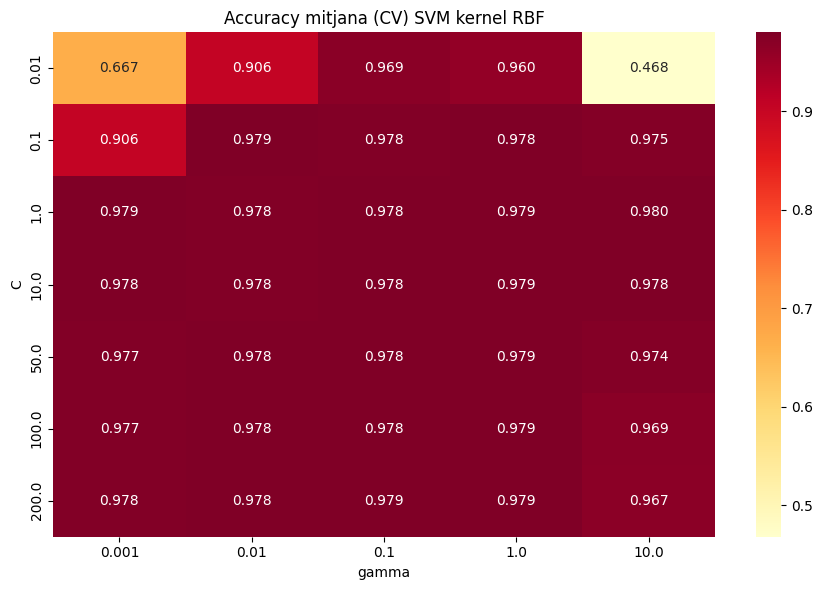

In [11]:
# graella per al cross-validation
param_grid_svm = {
    'C':     [0.01, 0.1, 1, 10, 50, 100, 200],
    'gamma': [0.001, 0.01, 0.1, 1, 10]
}
cv_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_svm = GridSearchCV(
    SVC(kernel='rbf'),
    param_grid=param_grid_svm,
    cv=cv_svm,
    scoring='accuracy',
    n_jobs=-1
)
grid_svm.fit(X_train_2d, y_train)

print(f"millors params SVM: {grid_svm.best_params_}")
print(f"millor accuracy CV:     {grid_svm.best_score_:.4f}")

# calculem la mitjana de l'accuracy per plotejar el heatmap
mean_scores = grid_svm.cv_results_['mean_test_score'].reshape(
    len(param_grid_svm['C']), len(param_grid_svm['gamma'])
)

# heatmap de l'accuracy
plt.figure(figsize=(9, 6))
sns.heatmap(
    pd.DataFrame(mean_scores, index=param_grid_svm['C'], columns=param_grid_svm['gamma']),
    annot=True, fmt=".3f", cmap="YlOrRd"
)
plt.xlabel("gamma")
plt.ylabel("C")
plt.title("Accuracy mitjana (CV) SVM kernel RBF")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<strong>Implementació:</strong>

Realitza els següents passos amb el dataset d'entrenament (_train_):

1. Entrena un model SVM utilitzant la millor combinació de paràmetres que hagis trobat.
2. Calcula l'*accuracy* (precisió) del model tant en les dades de _train_ com de _test_.
3. Calcula la matriu de confusió utilitzant les dades de _test_.
4. Representa gràficament la frontera de decisió amb les dades de _test_.

Aquest procés et permetrà veure com la millor combinació de paràmetres millora l'efectivitat del teu model SVM en la classificació de les dades.
</div>

Millors paràmetres: C=1, gamma=10
Accuracy en train (SVM): 0.9808
Accuracy en test  (SVM): 0.9720


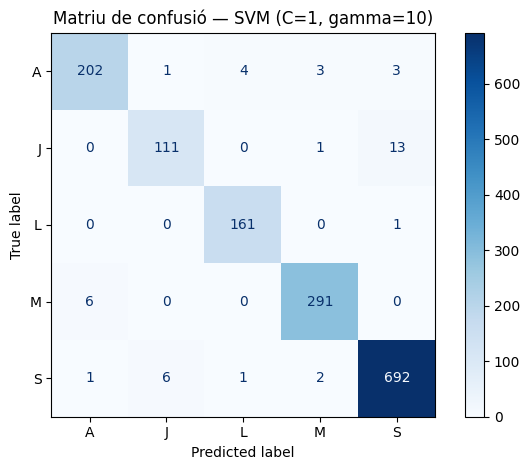

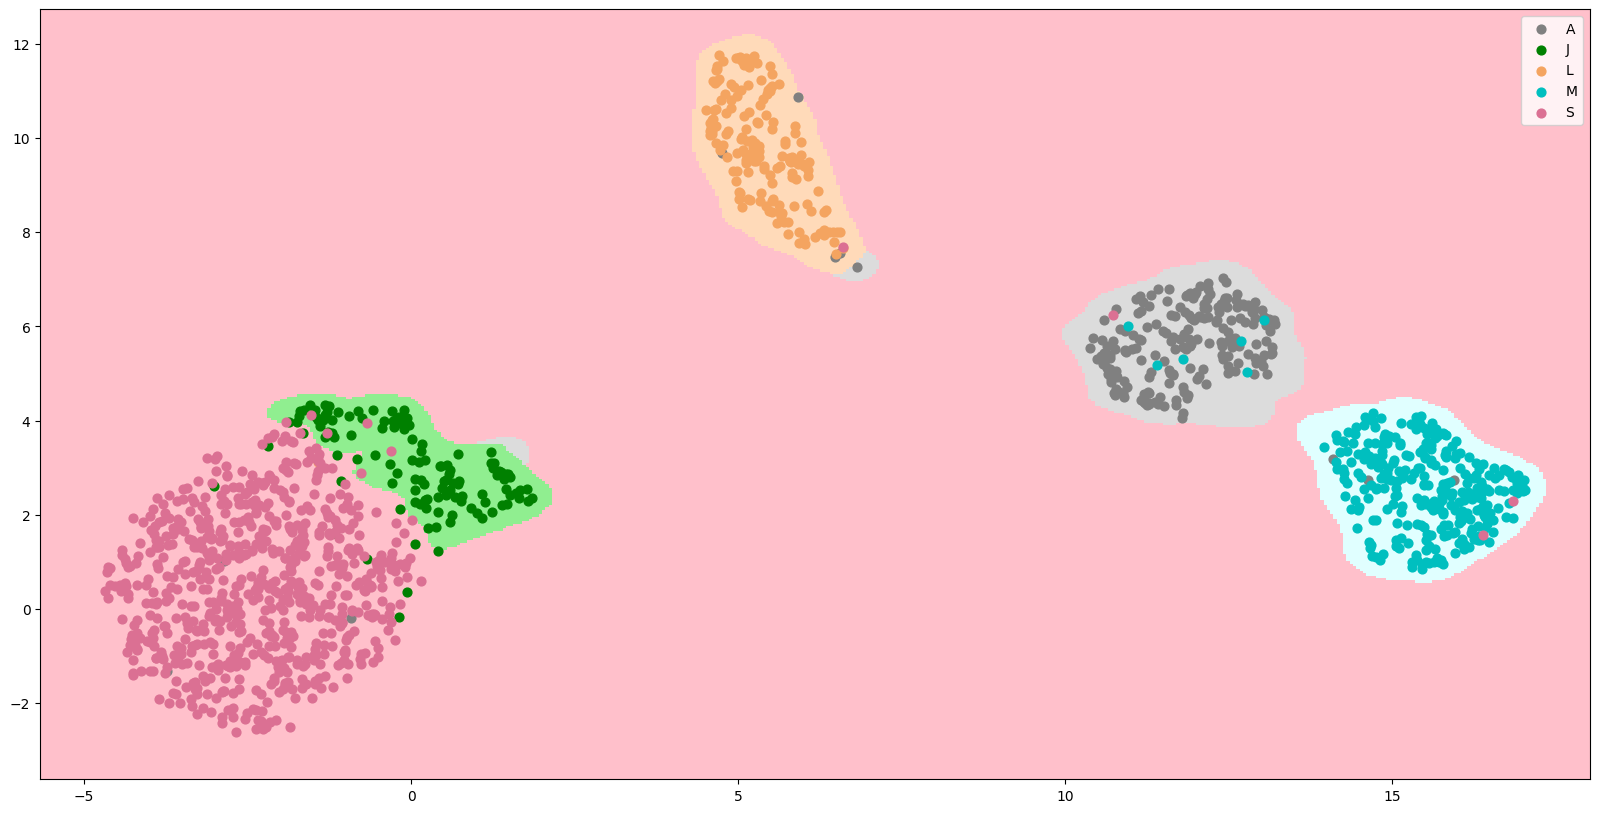

In [12]:
best_C     = grid_svm.best_params_['C']
best_gamma = grid_svm.best_params_['gamma']

# entrenem SVM amb la millor combinació de paràmetres
svm_best = SVC(kernel='rbf', C=best_C, gamma=best_gamma)
svm_best.fit(X_train_2d, y_train)

# accuracy en train i test
acc_train_svm = accuracy_score(y_train, svm_best.predict(X_train_2d))
acc_test_svm  = accuracy_score(y_test,  svm_best.predict(X_test_2d))
print(f"Millors paràmetres: C={best_C}, gamma={best_gamma}")
print(f"Accuracy en train (SVM): {acc_train_svm:.4f}")
print(f"Accuracy en test  (SVM): {acc_test_svm:.4f}")

# matriu de confusió
cm_svm = confusion_matrix(y_test, svm_best.predict(X_test_2d))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=labels)
disp.plot(cmap='Blues')
plt.title(f"Matriu de confusió — SVM (C={best_C}, gamma={best_gamma})")
plt.tight_layout()
plt.show()

# fronteres de decisió
plot_decision_boundaries(svm_best, X_test_2d, y_test)

<div class="alert alert-block alert-info">
<strong>Anàlisi:</strong>

1. Comenta els resultats obtinguts en la cerca dels millors hiperparàmetres. Reflexiona sobre com va variar el rendiment del model SVM amb els diferents valors de _C_ i _gamma_. Considera si els valors òptims trobats tenen sentit en el context del teu conjunt de dades.
2. Examina les fronteres de decisió que has generat amb el model SVM. La forma d'aquestes fronteres és coherent amb el que esperaries de l'algoritme utilitzat? Pensa en com la combinació d'hiperparàmetres seleccionats podria influir en la forma de les fronteres.
3. Avalua les prediccions realitzades sobre el conjunt de test. Observa la seva precisió i com es distribueixen en relació amb les fronteres de decisió. Són aquestes prediccions consistents amb el que observes en les fronteres de decisió?

Aquest anàlisi t'ajudarà a comprendre l'eficàcia del model SVM amb els hiperparàmetres seleccionats i el seu impacte en la classificació de les dades."
</div>

Preguntes 1 i 2:

- Les fronteres de svm amb kernel RBF no són lineals (bueno, per ser precisos, són lineals en alguna dimensió) i formen regions arrodonides que s'adapten a l'estructura de les dades. S'hi adapten més o menys depenent dels paràmetres, com explico en els següents punts:

- C regula el compromís entre el marge i els errors classificats. Amb C baix tenim marge gran però bastants errores de classificació, i amb C alt s'intenta classificar-ho tot correctament (risc d'overfitejar el model). El valor C òptim ha sigut un valor intermedi, la qual cosa té tot el sentit del món en el nostre cas. En efecte, si mirem les nostres dades, podem veure que per exemple hi ha punts blaus que estan just en mig dels grisos. Això segur que també passa al conjunt de train i, per tant, si el model volgués classificar-ho tot bé durant l'entrenament, seguríssim que seria massa específic i estaria overfitejat.

- Gamma controla el radi d’influència dels punts de train. Amb gamma petit, cada punt té influència llunyana i la frontera és més suau i global (pot provocar underfitting). Amb gamma molt gran, la influència és molt local i la frontera es torna molt irregular (risc d’overfitejar). En el nostre cas, té sentit que un gamma alt funcioni bé perquè les classes formen grups compactes i la frontera només ha de ser localment flexible en zones de solapament, sobretot entre J i S. Tot i així, quan surt el valor màxim de la graella, és bona pràctica ampliar una mica el rang de gammes possibles i tornar a aplicar cv per comprovar si l'òptim real encara és més alt.

Pregunta 3:

- L'accuracy sobre test és del 97%, cosa que quadra amb el gràfic de fronteres, ja allà podem observar que la majoria de punts estan correctament classificats.

<a id='ej14'></a>
## 1.4. Arbres de decisió (1,25 punts)

En aquesta secció, exploraràs els arbres de decisió, models predictius que es basen en regles binàries (sí/no) per a classificar les observacions segons els seus atributs i predir el valor de la variable resposta. Aquests arbres poden ser classificadors, com en el teu exemple, o regressors per a predir variables contínues.

#### Construcció d'un Arbre

Per a construir un arbre, segueix l'algoritme de *recursive binary splitting*:

1. Comença a la part superior de l'arbre, on totes les observacions pertanyen a la mateixa regió.
2. Identifica tots els possibles punts de tall per a cadascun dels predictors. Aquests punts de tall són els diferents nivells dels predictors.
3. Avalua les possibles divisions per a cada predictor utilitzant una mesura específica. En els classificadors, aquestes mesures poden ser el *classification error rate*, l'índex Gini, l'entropia o el chi-square.

Comprendre aquests passos t'ajudarà a entendre com els arbres de decisió creen divisions binàries per a classificar les dades i com aquests poden aplicar-se tant per a classificació com per a regressió.

<div class="alert alert-block alert-info">
<strong>Implementació:</strong>

Segueix aquests passos:

1. Amb el dataset d'entrenament, entrena un arbre de decisió utilitzant el classificador `DecisionTreeClassifier` de la biblioteca `tree` de `sklearn`.
2. Calcula l'*accuracy* (precisió) del model tant en les dades de _train_ com de _test_.
3. Calcula la matriu de confusió utilitzant les dades de _test_.
4. Representa gràficament la frontera de decisió amb les dades de _test_.
5. Representa l'arbre de decisió. Pots utilitzar l'ordre `plot.tree` de la biblioteca `tree` de `sklearn`.

Aquests passos et permetran avaluar com l'arbre de decisió es comporta en el teu conjunt de dades, tant en termes de classificació com en la seva representació visual."
</div>

accuracy en train: 1.0000
accuracy en test: 0.9586


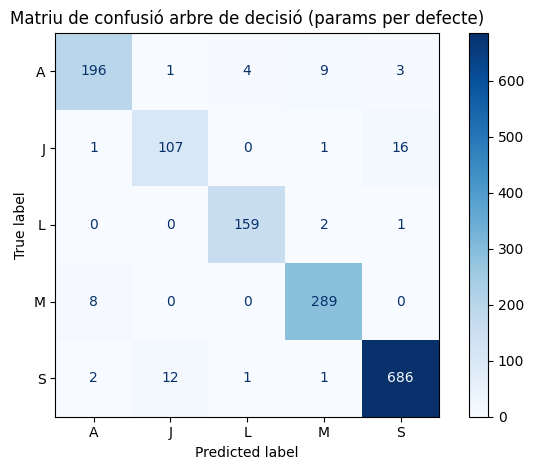

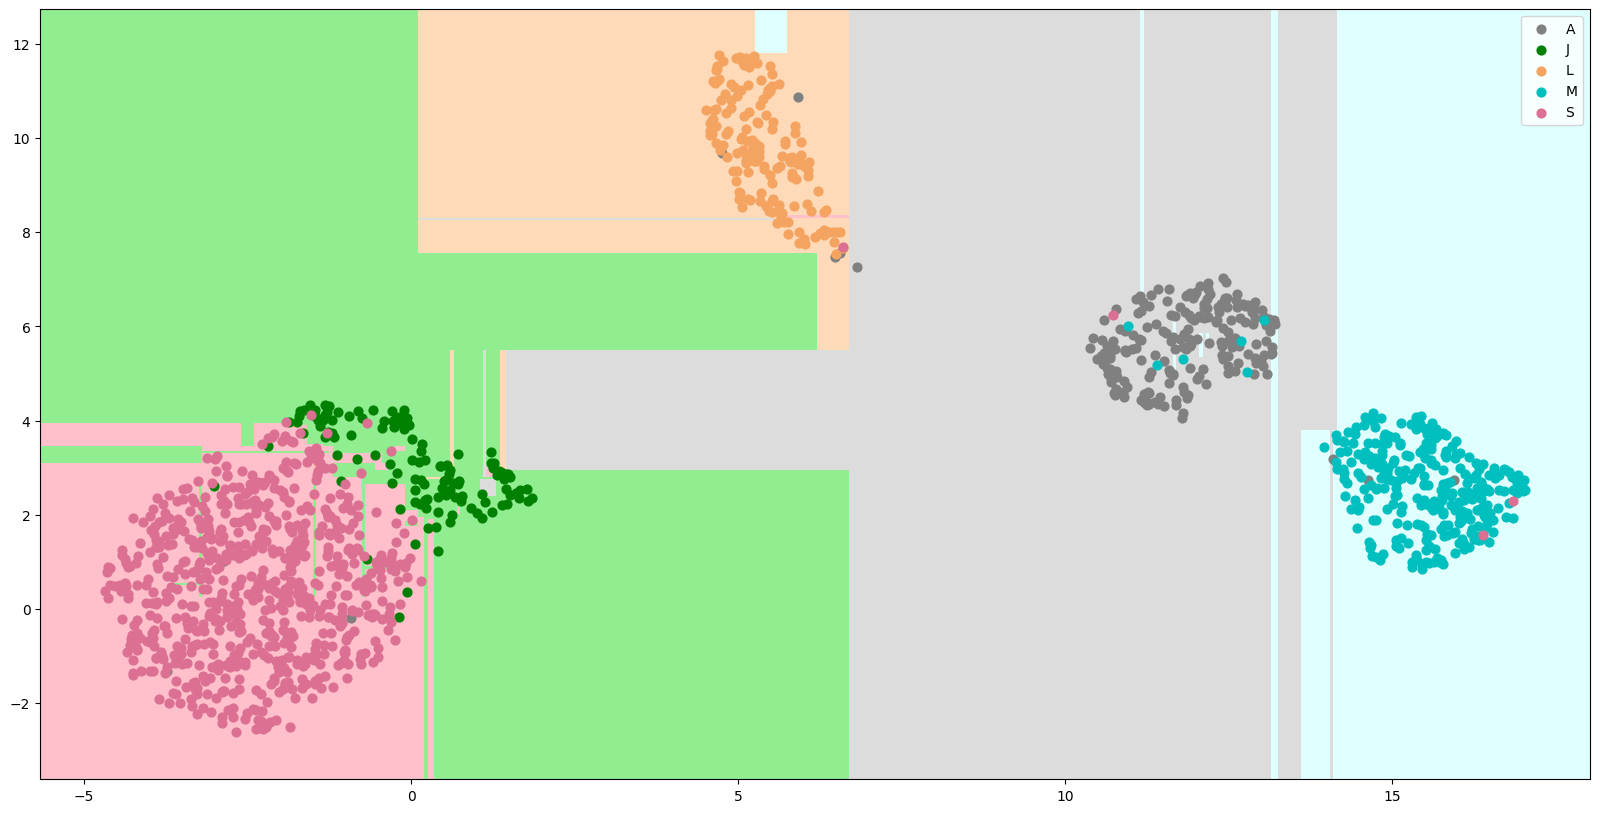

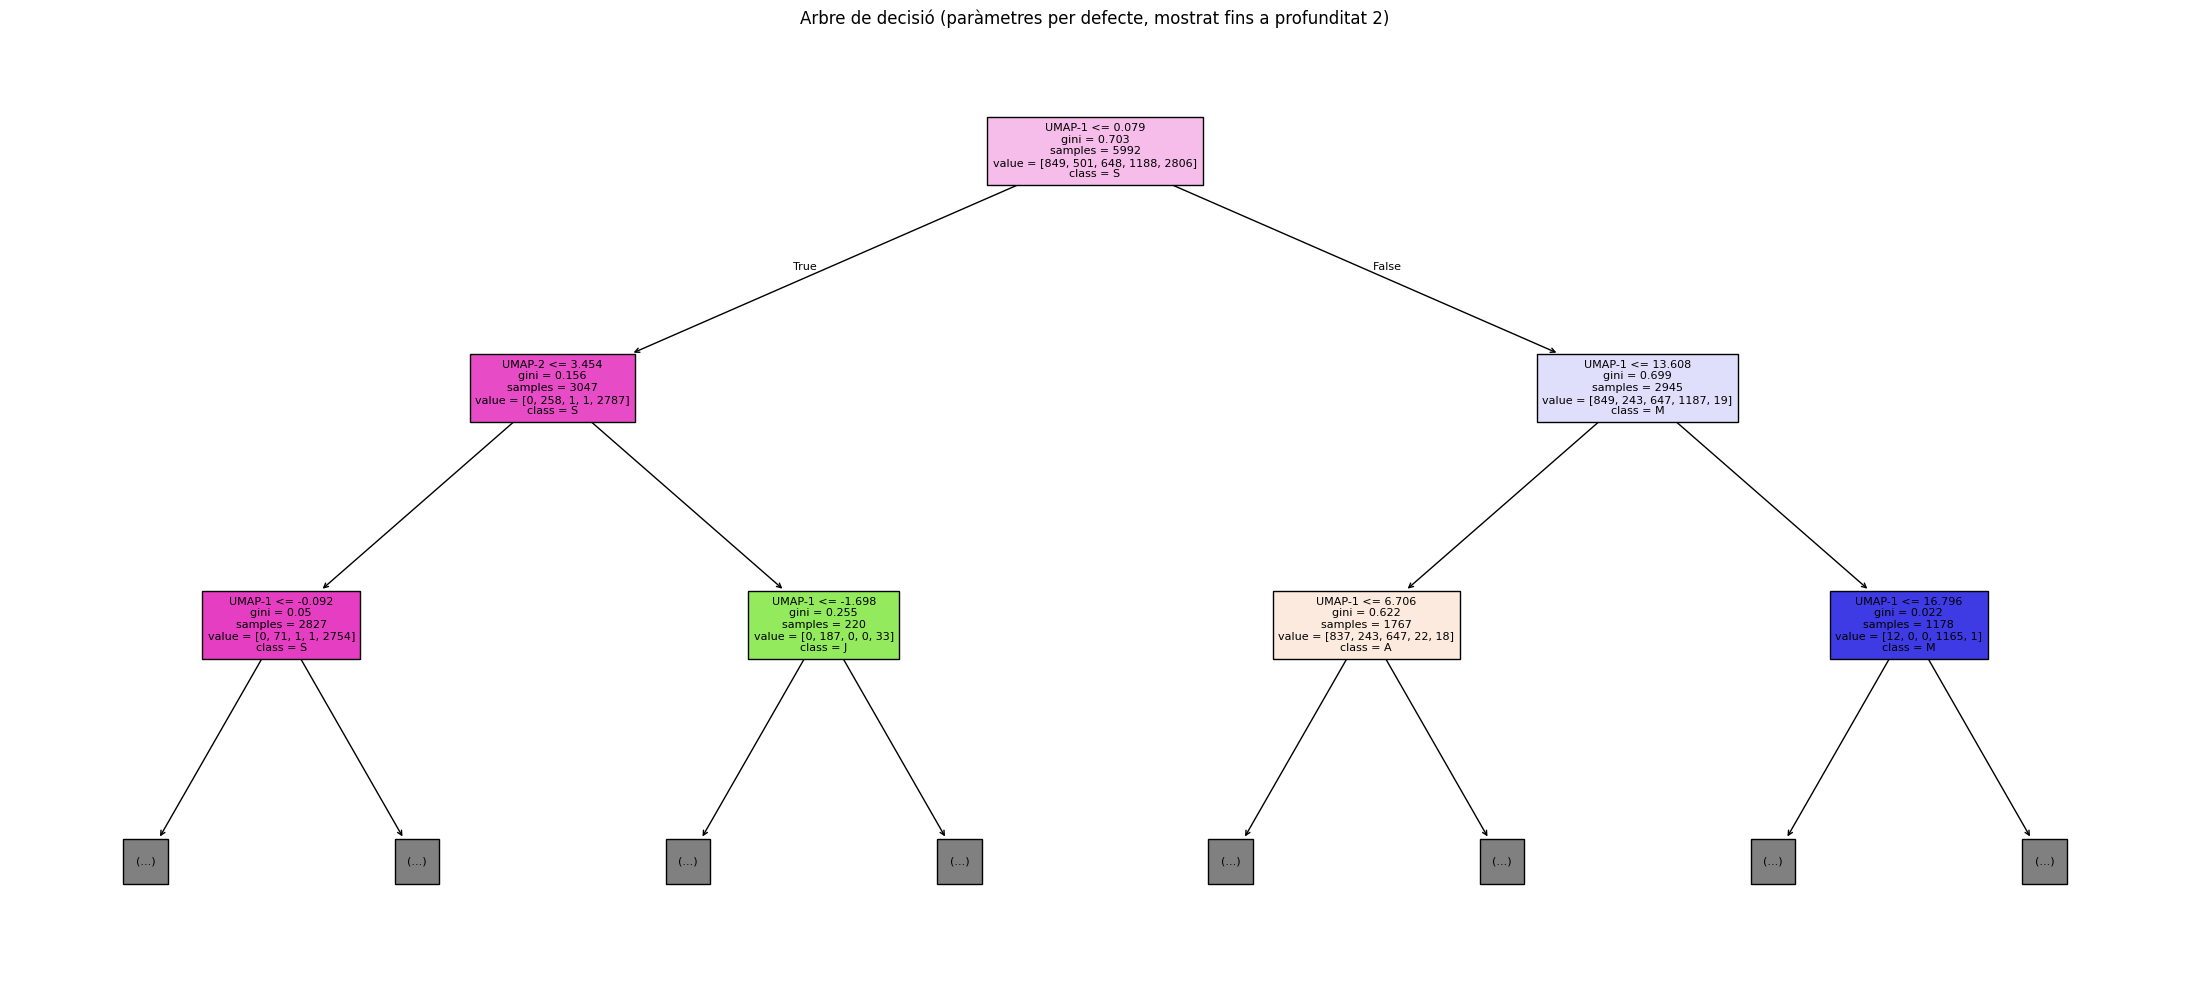

Profunditat màxima de l'arbre: 22


In [14]:
# entrenem un arbre de decisió sense restriccions (default params)
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train_2d, y_train)

# accuracy en train i test
acc_train_dt = accuracy_score(y_train, dt_default.predict(X_train_2d))
acc_test_dt  = accuracy_score(y_test,  dt_default.predict(X_test_2d))
print(f"accuracy en train: {acc_train_dt:.4f}")
print(f"accuracy en test: {acc_test_dt:.4f}")

# matriu de confusió
cm_dt = confusion_matrix(y_test, dt_default.predict(X_test_2d))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=labels)
disp.plot(cmap='Blues')
plt.title("Matriu de confusió arbre de decisió (params per defecte)")
plt.tight_layout()
plt.show()

# fronteres de decisió
plot_decision_boundaries(dt_default, X_test_2d, y_test)

# visualitzem l'arbre de decisió (limitem a profunditat 2)
plt.figure(figsize=(22, 10))
tree.plot_tree(
    dt_default,
    max_depth=2,
    class_names=labels,
    feature_names=["UMAP-1", "UMAP-2"],
    filled=True,
    fontsize=8
)
plt.title("Arbre de decisió (paràmetres per defecte, mostrat fins a profunditat 2)")
plt.tight_layout()
plt.show()
print(f"Profunditat màxima de l'arbre: {dt_default.get_depth()}")

<div class="alert alert-block alert-info">
<strong>Anàlisi:</strong>

1. Avalua i comenta els resultats obtinguts amb l'arbre de decisió. Considera tant l'*accuracy* del model en els conjunts de _train_ i _test_ com els resultats de la matriu de confusió.
2. Reflexiona sobre com la frontera de decisió visualitzada en el conjunt de _test_ s'alinea amb els resultats obtinguts. És coherent amb el que esperaries d'un arbre de decisió?
3. Observa la representació gràfica de l'arbre. Analitza com les diferents ramificacions i decisions preses en l'arbre expliquen el comportament del model i el seu impacte en la classificació de les dades.

Aquest anàlisi t'ajudarà a comprendre en profunditat el funcionament i l'eficàcia de l'arbre de decisió en el teu conjunt de dades específic.

</div>

Pregunta 1: 

- L'accuracy a train és 1, i a test és la més baixa que hem vist fins ara (96%). Això és un comportament típic dels arbres de decisió, ja que s'ajusten al conjunt d'entrenament, però després la seva generalitació no és tant bona si no es controlen els paràmetres.

Pregunta 2: 

- La forma de les fronteres de decisió que veiem tenen sentit, ja que els arbres de decisió van fent talls verticals o horitzontals
- Si mirem el dibuix, encara veiem de forma més clara l'overfitting que comentavem abans. Hi ha talls que són extremandament prims, fet que demostra que el model s'ha overfitejat i ha capturat soroll que no hauria d'haver capturat.

Pregunta 3:

- Podem observar que les primeres divisions (nodes superiors) tallen el conjunt de dades en particions grans i informatives. Però com que l'arbre és molt profunt (22), els nodes més profunds capturen soroll, com hem pogut observar també al dibuix de les fronteres. Necessitem limitar `max_depth` i `min_samples_split` per obtenir un arbre que generalitzi millor i no s'overfiteji.

#### Evitant l'*overfitting*

El procés de construcció d'arbres descrit tendeix a reduir ràpidament l'error d'entrenament, per la qual cosa generalment el model s'ajusta molt bé a les observacions utilitzades com a entrenament (conjunt de *train*). Com a conseqüència, els arbres de decisió tendeixen a l'*overfitting*.
   
Per a evitar l'*overfitting* en els arbres de decisió, és crucial que modifiquis certs hiperparàmetres del model de la següent manera:

1. Utilitza l'hiperparàmetre `max_depth`, que defineix la profunditat màxima de l'arbre. Hauràs d'explorar els valors entre 4 i 10 per a trobar l'equilibri adequat entre la complexitat del model i la seva capacitat per a generalitzar.
2. Estableix l'hiperparàmetre `min_samples_split`, que és el nombre mínim d'observacions que ha de tenir una fulla de l'arbre abans de considerar una divisió. Experimenta amb valors com 2, 10, 20, 50 i 100 per a assegurar-te que l'arbre no es torni massa específic per a les observacions d'entrenament.

Ajustant aquests hiperparàmetres, podràs controlar la tendència de l'arbre de decisió a sobreajustar-se al conjunt d'entrenament, millorant així la seva capacitat per a realitzar prediccions efectives en noves dades.

<div class="alert alert-block alert-info">
    <strong>Implementació:</strong>

1. Calcula el valor òptim dels hiperparàmetres `max_depth` i `min_samples_split` utilitzant una cerca de graella amb validació creuada. Aquest procés t'ajudarà a trobar els valors òptims que evitaran el sobreajustament.
2. Per a cada combinació de valors, calcula la seva mitjana i la desviació estàndard.
3. Fes un _heatmap_ per a visualitzar la precisió segons els diferents valors dels hiperparàmetres.

Utilitza el mòdul `GridSearchCV` de `sklearn` per a calcular els millors hiperparàmetres amb el classificador `DecisionTreeClassifier` de `tree` de `sklearn`. Per a la visualització del _heatmap_, empra la llibreria `Seaborn`.

Aquests passos et permetran identificar de manera efectiva i visual els valors de `max_depth` i `min_samples_split` que maximitzen la precisió del teu arbre de decisió, minimitzant el risc de sobreajustament.
</div>

millors paràmetres: {'max_depth': 6, 'min_samples_split': 2}
millor accuracy:    0.9763


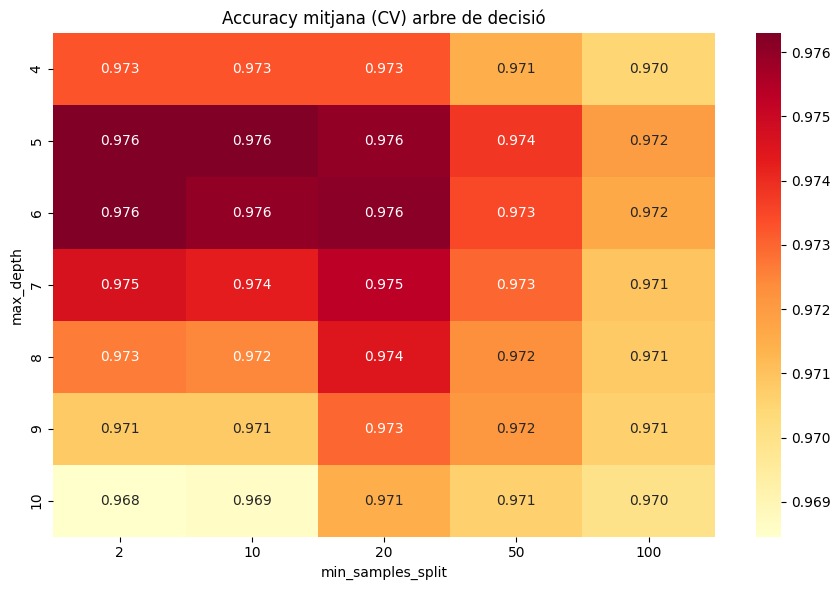

In [15]:
# graella per al cross-validation
param_grid_dt = {
    'max_depth':        [4, 5, 6, 7, 8, 9, 10],
    'min_samples_split': [2, 10, 20, 50, 100]
}
cv_dt = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=cv_dt,
    scoring='accuracy',
    n_jobs=-1
)
grid_dt.fit(X_train_2d, y_train)

print(f"millors paràmetres: {grid_dt.best_params_}")
print(f"millor accuracy:    {grid_dt.best_score_:.4f}")

# construïm el heatmap de l'accuracy
mean_scores_dt = grid_dt.cv_results_['mean_test_score'].reshape(
    len(param_grid_dt['max_depth']), len(param_grid_dt['min_samples_split'])
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    pd.DataFrame(
        mean_scores_dt,
        index=param_grid_dt['max_depth'],
        columns=param_grid_dt['min_samples_split']
    ),
    annot=True, fmt=".3f", cmap="YlOrRd"
)
plt.xlabel("min_samples_split")
plt.ylabel("max_depth")
plt.title("Accuracy mitjana (CV) arbre de decisió")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<strong>Implementació:</strong>


1. Entrena un arbre de decisió amb el dataset d'entrenament (_train_) utilitzant la millor combinació de paràmetres que hagis trobat.
2. Calcula l'*accuracy* (precisió) del model tant en les dades de _train_ com de _test_.
3. Calcula la matriu de confusió utilitzant les dades de _test_.
4. Representa gràficament la frontera de decisió amb les dades de _test_.
5. Representa l'arbre de decisió.

Aquests passos et permetran avaluar com l'arbre de decisió, ajustat amb els hiperparàmetres òptims, es comporta en el teu conjunt de dades, tant en termes de classificació com en la seva representació visual."
    
</div>

millors paràmetres: max_depth=6, min_samples_split=2
accuracy en train: 0.9831
accuracy en test: 0.9706


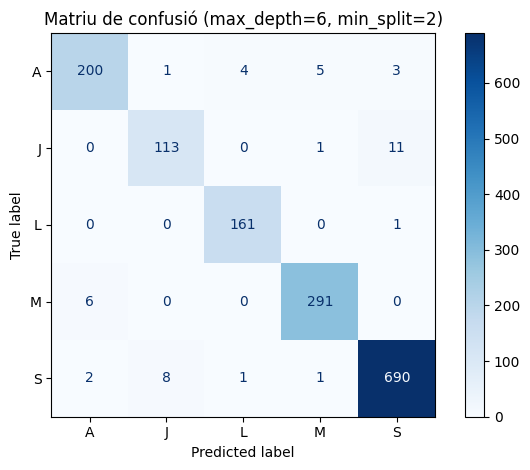

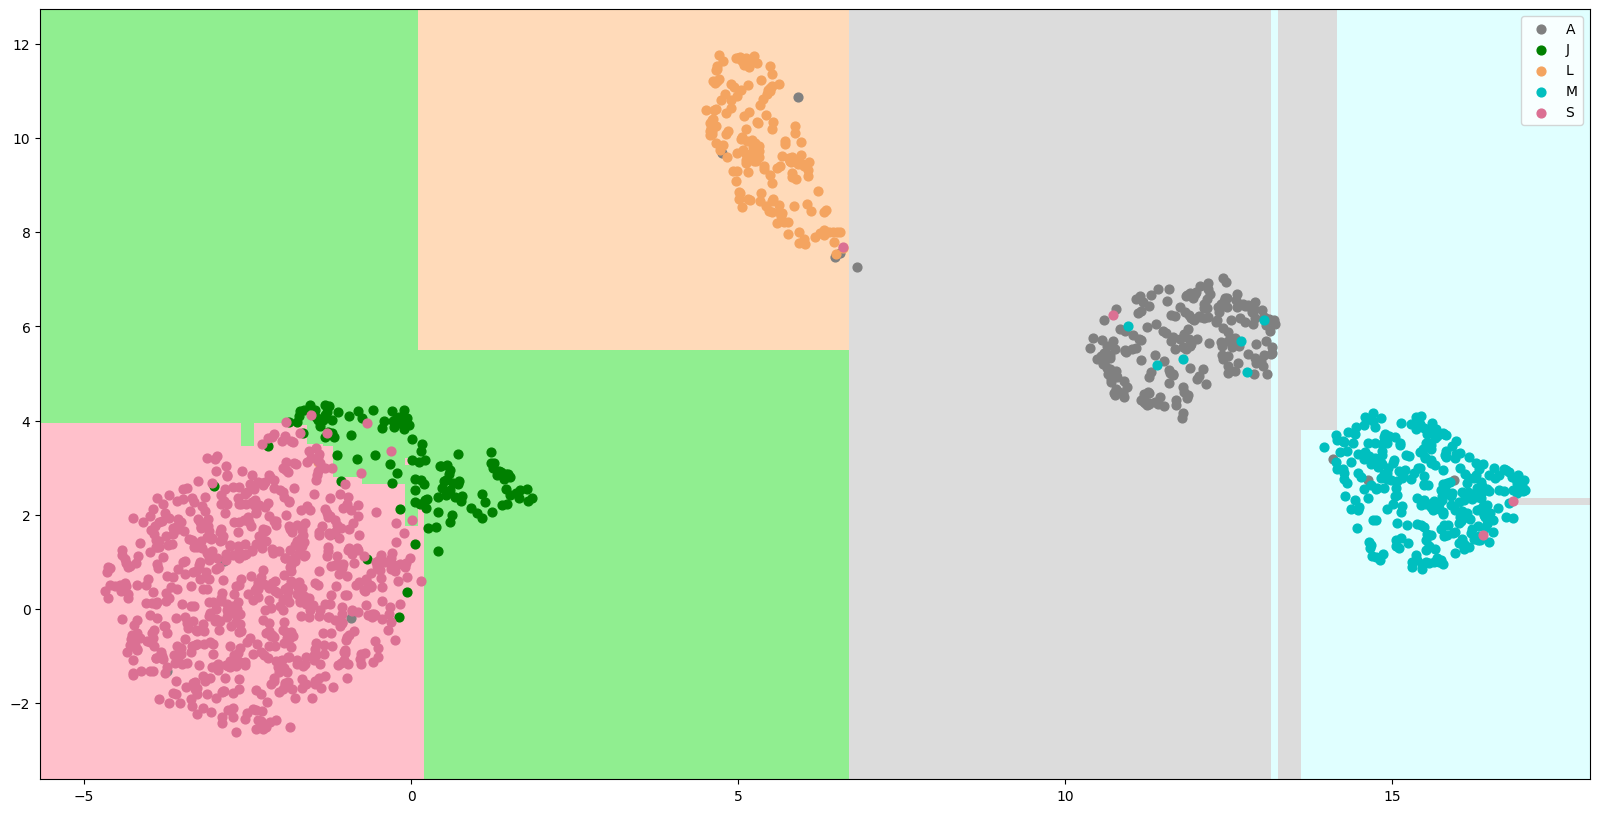

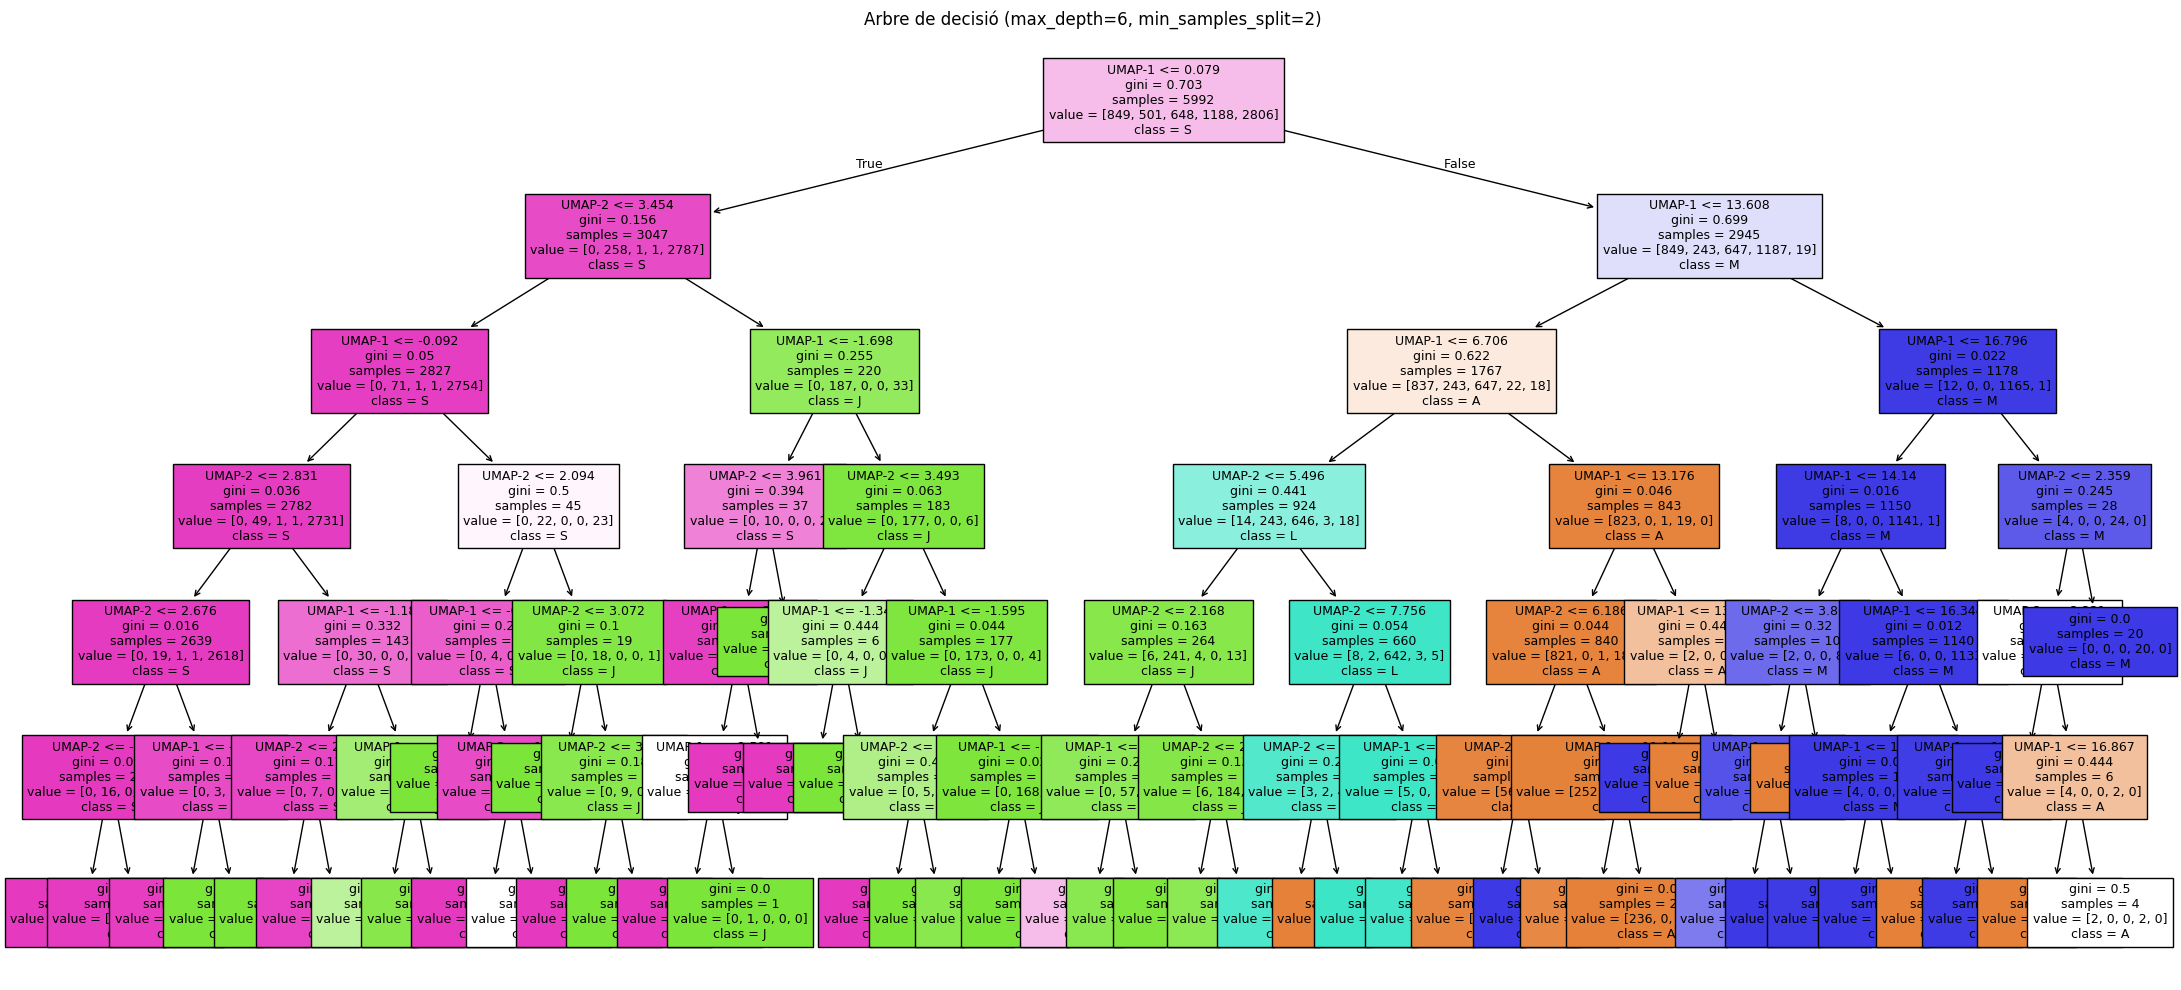

In [16]:
best_depth    = grid_dt.best_params_['max_depth']
best_min_split = grid_dt.best_params_['min_samples_split']

# enntrenem l'arbre amb la millor combinació de paràmetres
dt_best = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_split=best_min_split,
    random_state=42
)
dt_best.fit(X_train_2d, y_train)

# accuracy en train i test
acc_train_dt_best = accuracy_score(y_train, dt_best.predict(X_train_2d))
acc_test_dt_best  = accuracy_score(y_test,  dt_best.predict(X_test_2d))
print(f"millors paràmetres: max_depth={best_depth}, min_samples_split={best_min_split}")
print(f"accuracy en train: {acc_train_dt_best:.4f}")
print(f"accuracy en test: {acc_test_dt_best:.4f}")

# matriu de confusió
cm_dt_best = confusion_matrix(y_test, dt_best.predict(X_test_2d))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt_best, display_labels=labels)
disp.plot(cmap='Blues')
plt.title(f"Matriu de confusió (max_depth={best_depth}, min_split={best_min_split})")
plt.tight_layout()
plt.show()

# fronteres de decisió
plot_decision_boundaries(dt_best, X_test_2d, y_test)

# visualitzem l'arbre de decisió
plt.figure(figsize=(22, 10))
tree.plot_tree(
    dt_best,
    class_names=labels,
    feature_names=["UMAP-1", "UMAP-2"],
    filled=True,
    fontsize=9
)
plt.title(f"Arbre de decisió (max_depth={best_depth}, min_samples_split={best_min_split})")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<strong>Anàlisi:</strong>

1. Avalua i comenta els resultats obtinguts en la cerca dels millors hiperparàmetres. Considera com la combinació òptima de `max_depth` i `min_samples_split` ha impactat el rendiment de l'arbre de decisió.
2. Examina les fronteres de decisió generades amb el conjunt de _test_. Reflexiona sobre si la forma d'aquestes fronteres és coherent amb el que esperaries d'un arbre de decisió configurat amb aquests hiperparàmetres.
3. Analitza les prediccions realitzades sobre el conjunt de test. Observa la seva precisió i com es distribueixen en relació amb les fronteres de decisió. Són consistents aquestes prediccions amb l'estructura de l'arbre de decisió i les fronteres observades?

Aquest anàlisi t'ajudarà a comprendre l'eficàcia de l'arbre de decisió amb els hiperparàmetres seleccionats i el seu impacte en la classificació de les dades.
</div>

Pregunta 1:
- Els millors paràmetres són: profunditat màxima = 6 i min_samples =2. Queda confirmat que si l'arbre és massa profund s'overfiteja massa, i després generalitza malament. Observem que amb els millors paràmetres del CV, l'accuracy de train ha baixat (abans era 1), però la de test ha pujat (i.e. generalitza millor). 

Pregunta 2:
- Les fronteres amb els best_params tenen moltes menys regions primes que en el cas anterior, fet que posa de manifest el que comentavem (el model no se sobreajusta tant al conjunt de train).

Pregunta 3:
- L'accuracy a test és del 97%, i ja quadra amb el gràfic de les fronteres de decisió, ja que la majoria de punts estan correctament classificats. Veiem també que hi ha menys talls horitzontals i verticals, fet que confirma el max_depth = 6.

<a id='ej2'></a>
# 2. Implementació del cas pràctic (5 punts)

En aquest apartat treballarem amb un conjunt de dades real per a posar a prova els nostres coneixements.

<a id='ej21'></a>
## 2.1. Càrrega de dades (0,5 punts)

El conjunt de dades <i>Vehicle Dataset from CarDekho</i>, disponible a [Kaggle](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho), és un dataset tabular que recull informació sobre vehicles de segona mà obtinguda de plataformes de compravenda online. El seu objectiu principal és servir com a base per a tasques d'anàlisi de dades i aprenentatge automàtic, especialment en problemes de regressió com la predicció de preus de cotxes usats.

Aquest dataset inclou variables rellevants com el nom del vehicle, any de fabricació, preu de venda, quilòmetres recorreguts, tipus de combustible, tipus de venedor, transmissió i nombre de propietaris anteriors. Gràcies a aquesta combinació de característiques, permet estudiar com diferents factors influeixen en el valor de mercat d'un automòbil, sent molt utilitzat en exercicis educatius i projectes de machine learning enfocats en modelatge predictiu i anàlisi exploratòria de dades.

En primer lloc, carregarem el conjunt de dades i ens assegurarem que no tingui valors nuls.

<div class="alert alert-block alert-info">
<strong>Implementació:</strong>

1. Carrega el conjunt de dades des del fitxer `Car details v3.csv`.
2. Dona una ullada a les columnes resultants del Dataframe.
3. Queda't amb les variables que consideris oportunes i transforma les que necessitis transformar per a fer-les més manejables.
4. Imputa els valors que no vinguin en cas de fer falta.

</div>

In [28]:
df_cars = pd.read_csv('data/Car details v3-1.csv')
print("mida del dataset:", df_cars.shape)

mida del dataset: (8128, 13)


In [21]:
print("\nColumnes:")
print(df_cars.dtypes)


Columnes:
name                 str
year               int64
selling_price      int64
km_driven          int64
fuel                 str
seller_type          str
transmission         str
owner                str
mileage              str
engine               str
max_power            str
torque               str
seats            float64
dtype: object


In [ ]:
display(df_cars.head())

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


Anem a fer les transformacions corresponents de les columnes i ens quedarem amb les que realment ens interessin més.

In [ ]:
# Extraiem el valor numèric de 'mileage' (ex: "23.4 kmpl" → 23.4)
df_cars['mileage'] = df_cars['mileage'].str.extract(r'([\d.]+)').astype(float)

# Extraiem el valor numèric de 'engine' (ex: "1248 CC" → 1248)
df_cars['engine'] = df_cars['engine'].str.extract(r'([\d.]+)').astype(float)

# Extraiem el valor numèric de 'max_power' (ex: "74 bhp" → 74)
df_cars['max_power'] = df_cars['max_power'].str.extract(r'([\d.]+)').astype(float)

# La columna 'torque' és molt irregular. La descartem perquè és difícil d'extreure de forma fiable
# i ja tenim 'max_power' que en captura bona part de la informació de potència
df_cars.drop(columns=['torque'], inplace=True)

# La columna 'name' també la descartem. Si que en models més avançats podríem
# intentar extreure la marca i model, però la manera més senzilla de fer-ho seria 
# amb tècniques d'embeddings de text i no és l'objectiu d'aquest exercici
df_cars.drop(columns=['name'], inplace=True)

In [ ]:
display(df_cars.head())

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0


In [32]:
# mirem percentatge de valors nuls per columna
print(df_cars.isnull().sum())

year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        216
seats            221
dtype: int64


In [33]:
# Imputem valors nulls amb la mediana per a les columnes numèriques
for col in ['mileage', 'engine', 'max_power', 'seats']:
    df_cars[col] = df_cars[col].fillna(df_cars[col].median())

print("\nNulls després de la imputació:")
print(df_cars.isnull().sum())
print("\nForma final:", df_cars.shape)
display(df_cars.head())


Nulls després de la imputació:
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

Forma final: (8128, 11)


,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0


<a id='ej22'></a>
## 2.2. Anàlisi estadística bàsica i exploratòria de dades (1,5 punts)

En aquesta secció mirarem de comprendre com és la dada amb la qual treballarem. Quina millor manera de fer-ho, com a primera presa de contacte, que realitzar una anàlisi estadística bàsica i exploratòria de les dades tal com hem realitzat en altres activitats prèvies.

<div class="alert alert-block alert-info">
<strong>Implementació:</strong>
realitza l'anàlisi estadística bàsica i l'exploratori de les dades.

</div>

In [36]:
# Estadística descriptiva de les numèriques
num_cols = df_cars.select_dtypes(include=[np.number]).columns
display(df_cars[num_cols].describe().T)

# Estadística descriptiva de les categòrqiues
cat_cols = df_cars.select_dtypes(exclude=[np.number]).columns
display(df_cars[cat_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
year,8128.0,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0000,2020.0
selling_price,8128.0,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0000,10000000.0
km_driven,8128.0,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0000,2360457.0
mileage,8128.0,19.415554,3.981922,0.0,16.8,19.3,22.2775,42.0
engine,8128.0,1452.898130,498.196720,624.0,1197.0,1248.0,1582.0000,3604.0
max_power,8128.0,91.264982,35.376388,0.0,68.1,82.0,101.2500,400.0
seats,8128.0,5.405389,0.948874,2.0,5.0,5.0,5.0000,14.0


,count,unique,top,freq
fuel,8128,4,Diesel,4402
seller_type,8128,3,Individual,6766
transmission,8128,2,Manual,7078
owner,8128,5,First Owner,5289


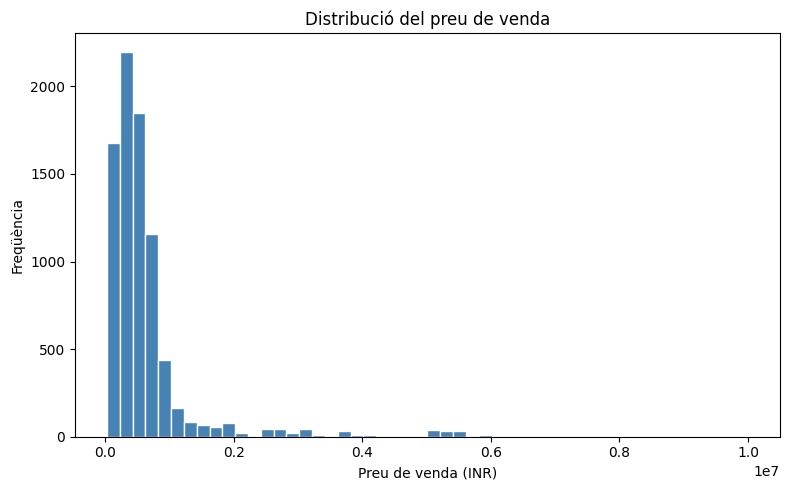

In [38]:
# Distribució de la variable objectiu (preu de venda)

plt.figure(figsize=(8, 5))
plt.hist(df_cars['selling_price'], bins=50, color='steelblue', edgecolor='white')
plt.title("Distribució del preu de venda")
plt.xlabel("Preu de venda (INR)")
plt.ylabel("Freqüència")
plt.tight_layout()
plt.show()

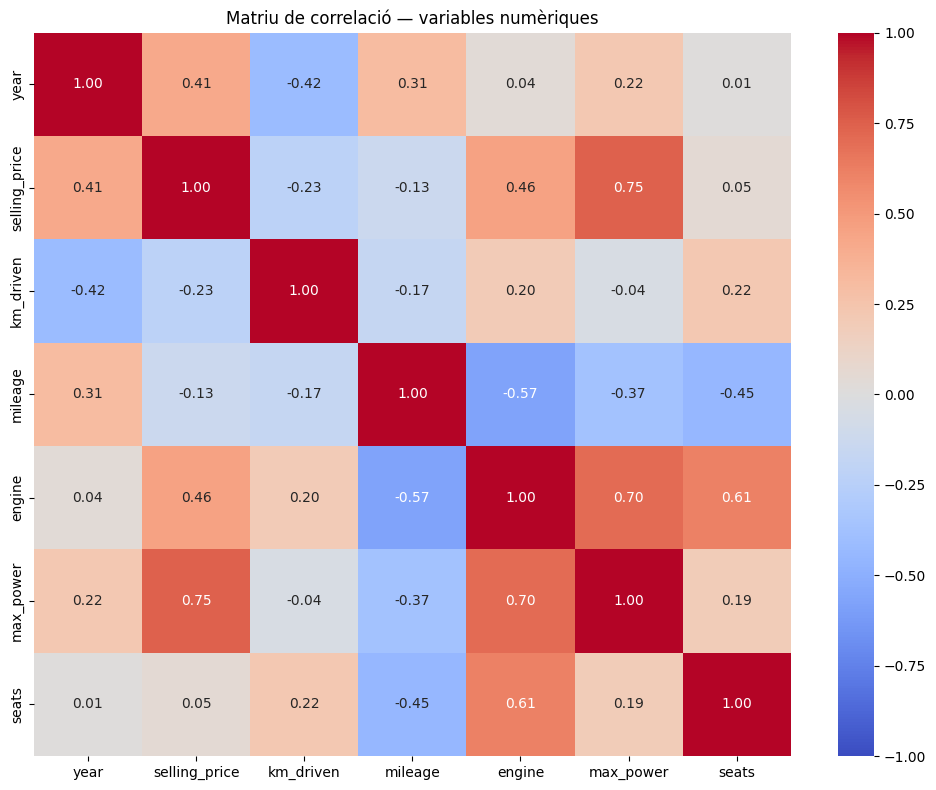

In [39]:
# Correlació entre variables numèriques
num_cols = ['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
plt.figure(figsize=(10, 8))
sns.heatmap(df_cars[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriu de correlació — variables numèriques")
plt.tight_layout()
plt.show()

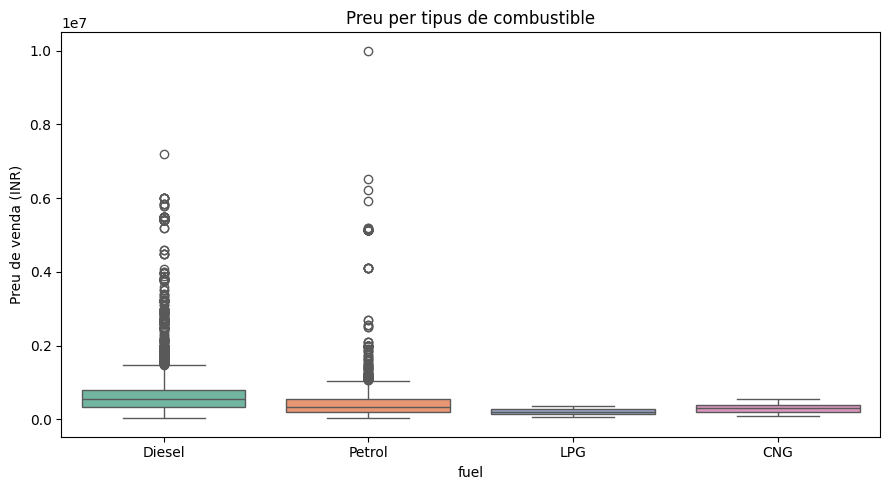

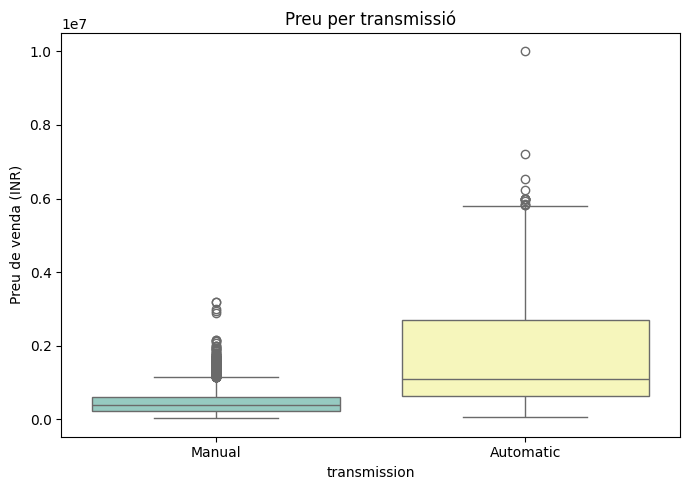

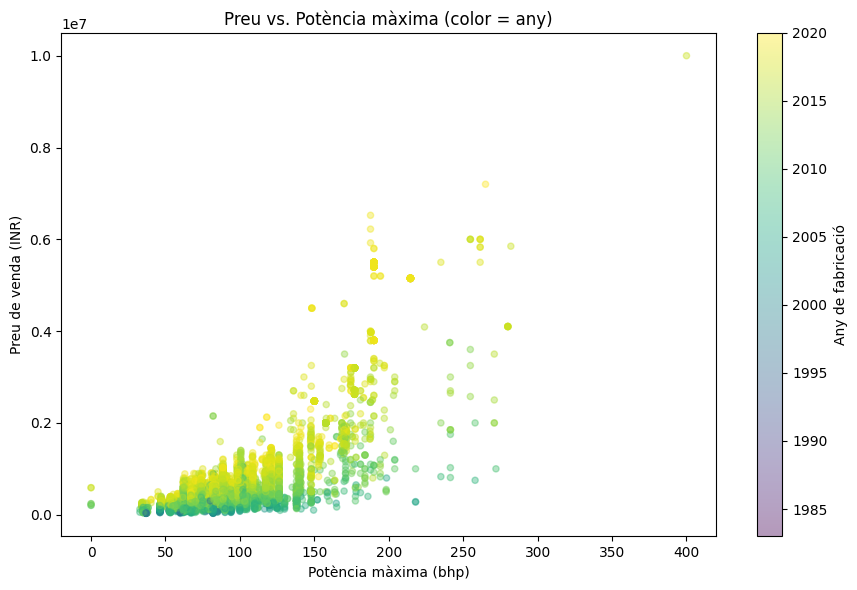

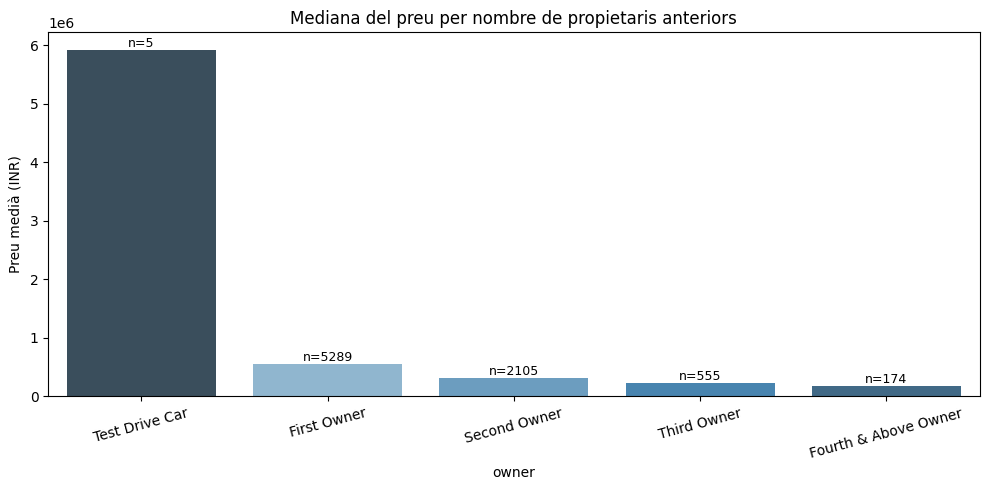

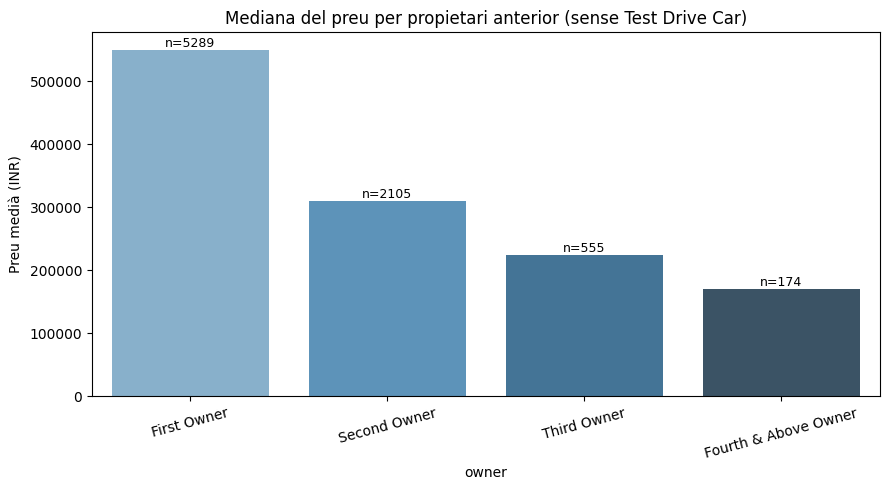

In [45]:
# Preu de venda per tipus de combustible
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_cars, x='fuel', y='selling_price', hue='fuel', palette='Set2', legend=False)
plt.title("Preu per tipus de combustible")
plt.ylabel("Preu de venda (INR)")
plt.tight_layout()
plt.show()

# Preu de venda per transmissió
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_cars, x='transmission', y='selling_price', hue='transmission', palette='Set3', legend=False)
plt.title("Preu per transmissió")
plt.ylabel("Preu de venda (INR)")
plt.tight_layout()
plt.show()

# Relació preu - max_power - any
plt.figure(figsize=(9, 6))
sc = plt.scatter(df_cars['max_power'], df_cars['selling_price'],
                 c=df_cars['year'], cmap='viridis', alpha=0.4, s=20)
plt.colorbar(sc, label='Any de fabricació')
plt.xlabel("Potència màxima (bhp)")
plt.ylabel("Preu de venda (INR)")
plt.title("Preu vs. Potència màxima (color = any)")
plt.tight_layout()
plt.show()

# Preu per propietari anterior (mediana)
plt.figure(figsize=(10, 5))
order_owner = df_cars.groupby('owner')['selling_price'].median().sort_values(ascending=False).index
ax = sns.barplot(
    data=df_cars,
    x='owner',
    y='selling_price',
    hue='owner',
    order=order_owner,
    palette='Blues_d',
    estimator='median',
    errorbar=None,
    legend=False
)
plt.title("Mediana del preu per nombre de propietaris anteriors")
plt.ylabel("Preu medià (INR)")
plt.xticks(rotation=15)

# Mostrem al gràfic el nombre de mostres per cada categoria d'owner
counts_owner = df_cars['owner'].value_counts().reindex(order_owner)
medians_owner = df_cars.groupby('owner')['selling_price'].median().reindex(order_owner)
for i, owner in enumerate(order_owner):
    y_pos = medians_owner.loc[owner]
    ax.text(i, y_pos, f"n={counts_owner[owner]}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Mateix gràfic, excloent Test Drive Car per veure millor la resta de categories
df_cars_no_testdrive = df_cars[df_cars['owner'] != 'Test Drive Car'].copy()
order_owner_no_testdrive = (
    df_cars_no_testdrive.groupby('owner')['selling_price']
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(9, 5))
ax2 = sns.barplot(
    data=df_cars_no_testdrive,
    x='owner',
    y='selling_price',
    hue='owner',
    order=order_owner_no_testdrive,
    palette='Blues_d',
    estimator='median',
    errorbar=None,
    legend=False
)
plt.title("Mediana del preu per propietari anterior (sense Test Drive Car)")
plt.ylabel("Preu medià (INR)")
plt.xticks(rotation=15)

counts_owner_no_testdrive = df_cars_no_testdrive['owner'].value_counts().reindex(order_owner_no_testdrive)
medians_owner_no_testdrive = df_cars_no_testdrive.groupby('owner')['selling_price'].median().reindex(order_owner_no_testdrive)
for i, owner in enumerate(order_owner_no_testdrive):
    y_pos = medians_owner_no_testdrive.loc[owner]
    ax2.text(i, y_pos, f"n={counts_owner_no_testdrive[owner]}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<strong>Anàlisi:</strong>
quines conclusions en pots treure de l'anàlisi?

</div>

- La variable selling_price està esbiaixada cap a l'esquerra. La majoria de cotxes estan en preus baixos o mitjans, i després hi ha pocs cotxes molt cars que estiren molt la cua del gràfic.

- A la matriu de correlació es veu bastant clar que max_power és la variable més relacionada amb el preu, i també engine i year tenen relació positiva. En canvi km_driven va a la contra (com més km, menys preu), que és bastant logic.

- Als boxplots de fuel i transmission es veu que no totes les categories juguen al mateix nivell. Petrol i Diesel tenen molta més dispersió i molts outliers cap amunt. I en transmissió, l'automatic normalment queda per sobre del manual.

- Al scatter de max_power vs preu (color per any) es veu una tendencia bastant clara: quan puja la potència, acostuma a pujar el preu. A més, els anys més recents tendeixen a concentrar-se en zones de preu més alt.

- Amb el barplot de owner es veu que Test Drive Car és una categoria molt especial, ja que té molt poques mostres i una mediana molt alta. O sigui, distorsiona bastant la lectura global si el poses junt amb la resta.

- El segon barplot (on he tret Test Drive Car), deixa molt més clar el patro real: First Owner té la mediana més alta, després Second, després Third i finalment Fourth & Above. O sigui, a més propietaris previs, menor valor de revenda en general. Cosa que podíem esperar 100%.

<a id='ej23'></a>
## 2.3. Preprocessament de dades (1,5 punts)

En aquesta secció prepararem el conjunt de dades per a entrenar un model de regressió.

<div class="alert alert-block alert-info">
<strong>Implementació:</strong>

1. Si no ho has fet encara, separa el conjunt de dades en atributs descriptius (X) i variable objectiu (y).
2. Divideix el conjunt de dades en els subconjunts d'entrenament i test amb els quals treballarem d'ara endavant.
3. Si s'aplica, transforma els atributs descriptius categòrics en atributs numèrics.
4. En el cas de ser necessari, estandarditza el conjunt de dades.

</div>

In [ ]:
# 1. Separació en X (atributs) i y (variable objectiu)
y_cars = df_cars['selling_price'].copy()
X_cars = df_cars.drop(columns=['selling_price']).copy()

# 2. Divisió train/test (80/20, random_state=42)
X_cars_train, X_cars_test, y_cars_train, y_cars_test = train_test_split(
    X_cars, y_cars, test_size=0.2, random_state=42
)
print(f"Train: {X_cars_train.shape} | Test: {X_cars_test.shape}")

# 3. Codificació de variables categòriques
# fuel, seller_type, transmission -> One-Hot Encoding (no cap ordre natural)
# owner -> Ordinal Encoding (hi ha un ordre: First < Second < Third < Fourth & Above < Test Drive)
owner_order = [
    ['First Owner', 'Second Owner', 'Third Owner',
     'Fourth & Above Owner', 'Test Drive Car']
]

ordinal_enc = OrdinalEncoder(categories=owner_order)
X_cars_train = X_cars_train.copy()
X_cars_test  = X_cars_test.copy()

X_cars_train['owner_enc'] = ordinal_enc.fit_transform(X_cars_train[['owner']])
X_cars_test['owner_enc']  = ordinal_enc.transform(X_cars_test[['owner']])

X_cars_train.drop(columns=['owner'], inplace=True)
X_cars_test.drop(columns=['owner'], inplace=True)

# One-Hot Encoding per a fuel, seller_type i transmission
X_cars_train = pd.get_dummies(X_cars_train, columns=['fuel', 'seller_type', 'transmission'], drop_first=False)
X_cars_test  = pd.get_dummies(X_cars_test,  columns=['fuel', 'seller_type', 'transmission'], drop_first=False)

# Assegurem que train i test tinguin les mateixes columnes
X_cars_train, X_cars_test = X_cars_train.align(X_cars_test, join='left', axis=1, fill_value=0)
X_cars_train = X_cars_train.fillna(0).astype(float)
X_cars_test  = X_cars_test.fillna(0).astype(float)

print("Forma de X_cars_train:", X_cars_train.shape)
print("Columnes:", X_cars_train.columns.tolist())

# 4. L'algoritme triat (RandomForest) no requereix estandardització
# però l'aplicarem igualment per permetre comparar amb TabPFN (que tampoc la requereixi)
# i com a bona pràctica per al pipeline
scaler_cars = StandardScaler()
X_cars_train_sc = scaler_cars.fit_transform(X_cars_train)
X_cars_test_sc  = scaler_cars.transform(X_cars_test)

print("\nPreprocessament completat.")

<div class="alert alert-block alert-info">
<strong>Anàlisi:</strong>

1. Si vas transformar alguna variable categòrica en numèrica explica breument l'elecció de la tècnica utilitzada en cada cas.
2. Justifica per què és necessari o no estandarditzar la dada.

</div>

1. Transformació de variables categòriques:

- owner l'he codificat amb Ordinal Encoding, perquè aqui sí que hi ha un ordre bastant natural (first owner, second owner, etc). Em semblava que així el model podia captar millor aquesta info.
- fuel, seller_type i transmission les he passat amb One-Hot Encoding, perquè no tenen ordre natural. Si ho codifiques com 0,1,2... li estàs passant un ordre que no existeix.

2. Estandardització:

- En aquest cas, amb models basats en arbres (com random forest o gradient boosting) no és estrictament necessari estandarditzar, perquè no treballen amb distancies.
- Tot i així, ho he fet igual per tenir el pipeline més net i per si més endavant vull provar algun model que sí que sigui sensible a escala.

<a id='ej24'></a>
## 2.4. Modelització (1 punt)

Amb les dades degudament carregades i preparades, és el moment d'aplicar algun dels mètodes de regressió que hem vist a la teoria.

<div class="alert alert-block alert-info">
<strong>Implementació:</strong>

1. Tria el mètode de regressió que vulguis utilitzar per a predir el preu de venda.
2. Entrena el model de regressió triat i predeu el preu dels vehicles per als subconjunts d'entrenament i test.
3. Tria una mètrica per a poder avaluar el comportament del teu model.

</div>

Millors paràmetres (CV): {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Millor RMSE CV (test folds): 202,396 INR
Train (RF) → R²=0.9943 | RMSE=60,724 INR | MAE=28,562 INR
Test  (RF) → R²=0.9687 | RMSE=143,291 INR | MAE=70,165 INR


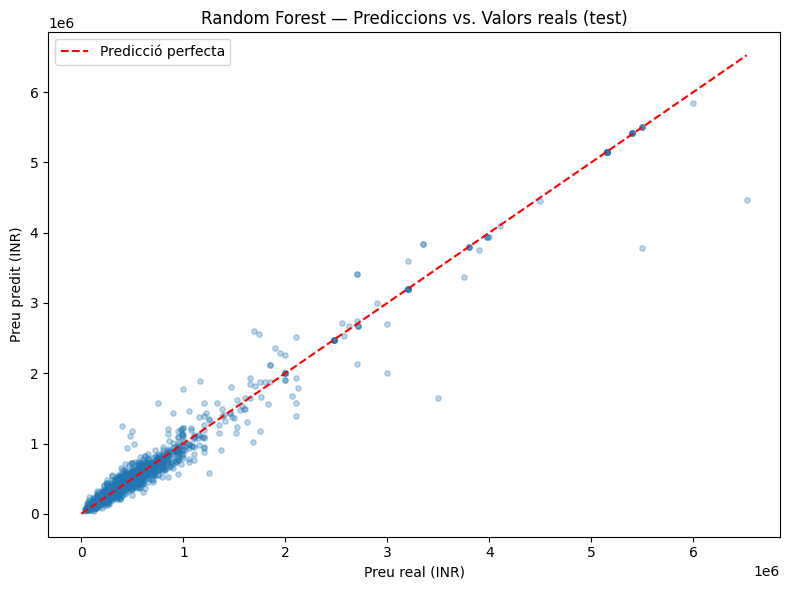

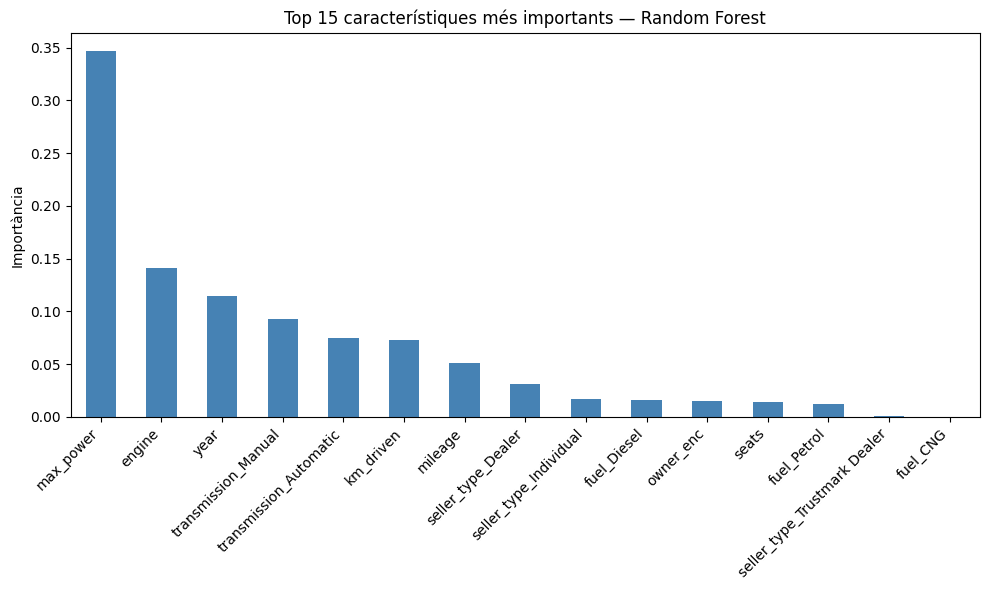

In [54]:
# 1. Fem servir Random Forest Regressor
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Grid Search amb CV sobre el subset de test (tal com demana l'enunciat adaptat)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
 )
grid_rf.fit(X_cars_test, y_cars_test)

print("Millors paràmetres (CV):", grid_rf.best_params_)
print(f"Millor RMSE CV (test folds): {-grid_rf.best_score_:,.0f} INR")

# Entrenem el model final amb la millor combinació trobada
rf_best = RandomForestRegressor(
    **grid_rf.best_params_,
    random_state=42,
    n_jobs=-1
)
rf_best.fit(X_cars_train, y_cars_train)

# 2. Prediccions en train i test
y_pred_rf_train = rf_best.predict(X_cars_train)
y_pred_rf_test  = rf_best.predict(X_cars_test)

# 3. Mètriques d'avaluació
def print_metrics(label, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"{label} → R²={r2:.4f} | RMSE={rmse:,.0f} INR | MAE={mae:,.0f} INR")

print_metrics("Train (RF)", y_cars_train, y_pred_rf_train)
print_metrics("Test  (RF)", y_cars_test,  y_pred_rf_test)

# Gràfica de prediccions vs. valors reals (test)
plt.figure(figsize=(8, 6))
plt.scatter(y_cars_test, y_pred_rf_test, alpha=0.3, s=15)
max_val = max(y_cars_test.max(), y_pred_rf_test.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Predicció perfecta')
plt.xlabel("Preu real (INR)")
plt.ylabel("Preu predit (INR)")
plt.title("Random Forest — Prediccions vs. Valors reals (test)")
plt.legend()
plt.tight_layout()
plt.show()

# Importància de les característiques
feat_imp = pd.Series(rf_best.feature_importances_, index=X_cars_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='bar', color='steelblue')
plt.title("Top 15 característiques més importants — Random Forest")
plt.ylabel("Importància")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<strong>Anàlisi:</strong>

1. Explica breument què et va fer triar la tècnica de regressió que finalment vas utilitzar.
2. Explica per què vas triar la mètrica amb la qual has avaluat el model.
3. Comenta els resultats obtinguts.

</div>


- He triat Random Forest Regressor perquè és un model robust per dades tabulars, no requereix gaire preprocesat i encaixa amb les tècniques que estem treballant a la pràctica (KNN, SVM i Random Forest). A més, permet interpretar quines variables pesen més en la predicció.

- He fet servir R², RMSE i MAE perquè juntes donen una visió completa. R² indica quanta variabilitat del preu expliquem; RMSE penalitza més els errors grossos; i MAE dona l'error mitjà en unitats de preu (INR), que és fàcil d'interpretar.

- Per ajustar el model he fet una cerca de paràmetres amb validació creuada i, amb la millor combinació trobada, els resultats finals són bons. En general, el model segueix bé la tendència dels valors reals i la predicció és força consistent, tot i que en els preus més alts acostuma a haver-hi una mica més d'error.

<a id='ej25'></a>
## 2.5. TabPFN (1 punt)

A la lectura de la publicació "[Actualitzar-se o quedar-se enrere: el que Kaggle em va ensenyar sobre algorismes i supervivència en ciència de dades] https://blogs.uoc.edu/informatica/ca/actualitzar-se-o-quedar-se-enrere-el-que-kaggle-em-va-ensenyar-sobre-algorismes-i-supervivencia-en-ciencia-de-dades/" que vam proposar al fòrum de l'assignatura, es parla d'una nova i revolucionària tècnica anomenada TabPFN.

En aquesta secció us proposem que la proveu amb el conjunt de dades de vehicles que hem estat preparant en aquesta segona meitat de l'activitat.

<div class="alert alert-block alert-info">
<strong>Implementació:</strong>

1. Instal·la TabPFN o tabpfn-client al teu ordenador.
2. Entrena un model de regressió TabPFN i predeu el preu dels vehicles per als subconjunts d'entrenament i test.
3. Utilitza la mateixa mètrica que vas emprar en el model anterior per a poder comparar quin model obté millors resultats en el conjunt de dades de vehicles.

</div>

<div class="alert alert-block alert-info">
<strong>Anàlisi:</strong>
avalua i comenta els resultats obtinguts amb TabPFN respecte al model que vas utilitzar en el subapartat anterior.
</div>

<div class="alert alert-block alert-success">
<strong>Resposta:</strong>


</div>